# EHRSHOT: аудит повторов диагнозов и copy-forwarding

Цель ноутбука — проверить, насколько повторяющиеся диагнозы раздувают историю пациента в задачах `guo_readmission` и `guo_icu`.

Что проверяем:

1. из каких типов событий состоит EHRSHOT;
2. почему diagnosis-scope берем как `condition_occurrence`, а не весь `SNOMED`;
3. какие diagnosis codes ведут себя как долгосрочные / chronic-like состояния;
4. насколько diagnosis sets повторяются между соседними reconstructed visits;
5. сколько повторов можно убрать из patient history до `prediction_time`.

Главное правило для всех task-level расчетов:

```text
event.time <= prediction_time
```

## 0. Setup

Ожидаемая структура такая же, как в предыдущих ноутбуках:

```text
EHRSHOT_MEDS/
  data/data.parquet
  metadata/codes.parquet
  metadata/subject_splits.parquet
  labels/guo_readmission/labels.parquet
  labels/guo_icu/labels.parquet
```

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

EHRSHOT_ROOT = Path("EHRSHOT_MEDS")
DATA_PATH = EHRSHOT_ROOT / "data" / "data.parquet"
METADATA_DIR = EHRSHOT_ROOT / "metadata"
CODES_PATH = METADATA_DIR / "codes.parquet"
SPLITS_PATH = METADATA_DIR / "subject_splits.parquet"
LABELS_DIR = EHRSHOT_ROOT / "labels"

RESULTS_DIR = Path("ehrshot_copy_forwarding_audit")
RESULTS_DIR.mkdir(exist_ok=True)

assert DATA_PATH.exists(), f"Не найден data.parquet: {DATA_PATH}"
assert SPLITS_PATH.exists(), f"Не найден subject_splits.parquet: {SPLITS_PATH}"
assert LABELS_DIR.exists(), f"Не найдена папка labels: {LABELS_DIR}"

print("EHRSHOT_ROOT:", EHRSHOT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("CODES_PATH:", CODES_PATH)
print("SPLITS_PATH:", SPLITS_PATH)
print("LABELS_DIR:", LABELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

EHRSHOT_ROOT: EHRSHOT_MEDS
DATA_PATH: EHRSHOT_MEDS/data/data.parquet
CODES_PATH: EHRSHOT_MEDS/metadata/codes.parquet
SPLITS_PATH: EHRSHOT_MEDS/metadata/subject_splits.parquet
LABELS_DIR: EHRSHOT_MEDS/labels
RESULTS_DIR: ehrshot_copy_forwarding_audit


In [2]:
events_lf = pl.scan_parquet(str(DATA_PATH))
splits = pl.read_parquet(SPLITS_PATH)

if CODES_PATH.exists():
    codes = pl.read_parquet(CODES_PATH)
else:
    codes = None

task_to_label_file = {
    p.parent.name: p
    for p in sorted(LABELS_DIR.glob("*/labels.parquet"))
}

SELECTED_TASKS = {
    "guo_readmission": {
        "task_description": "30-day readmission after discharge",
        "index_time": "23:59 в день выписки пациента",
        "target": "Повторная госпитализация после выписки",
        "horizon": "30 дней после выписки",
    },
    "guo_icu": {
        "task_description": "ICU transfer during current admission",
        "index_time": "23:59 в день госпитализации / admission",
        "target": "Перевод пациента в ICU",
        "horizon": "Текущая госпитализация / admission episode",
    },
}

for task_name in SELECTED_TASKS:
    assert task_name in task_to_label_file, f"Не найден label file для {task_name}"

print("Events schema:")
print(events_lf.collect_schema())

print("\nSplits:")
display(splits.group_by("split").agg(pl.len().alias("n_subjects")).to_pandas())

print("\nAvailable label tasks:")
for task_name in sorted(task_to_label_file):
    marker = "*" if task_name in SELECTED_TASKS else " "
    print(f"{marker} {task_name}")

if codes is not None:
    print("\nCodes schema:")
    print(codes.schema)
    display(codes.head(10).to_pandas())
else:
    print("\nNo codes.parquet found")

Events schema:
Schema({'subject_id': Int64, 'time': Datetime(time_unit='us', time_zone=None), 'code': String, 'numeric_value': Float32, 'text_value': String, 'unit': String, 'omop_table': String})

Splits:


,split,n_subjects
0,held_out,2212
1,train,2295
2,tuning,2232



Available label tasks:
  chexpert
* guo_icu
  guo_los
* guo_readmission
  lab_anemia
  lab_hyperkalemia
  lab_hypoglycemia
  lab_hyponatremia
  lab_thrombocytopenia
  new_acutemi
  new_celiac
  new_hyperlipidemia
  new_hypertension
  new_lupus
  new_pancan

Codes schema:
Schema({'code': String, 'description': String, 'parent_codes': List(String)})


,code,description,parent_codes
0,SNOMED/3950001,,None
1,Race/5,,None
2,Gender/F,,None
3,Ethnicity/Not Hispanic,,None
4,LOINC/68848-1,,None
5,LOINC/11506-3,,None
6,LOINC/2714-4,,None
7,LOINC/19218-7,,None
8,LOINC/3150-0,,None
9,LOINC/8310-5,,None


## 1. Вспомогательные функции

Здесь задаем общие правила:

- diagnosis-like события = `condition_occurrence`;
- static demographics (`Gender`, `Race`, `Ethnicity`) не считаем частью динамической sequence;
- labels подгружаем отдельно для `guo_readmission` и `guo_icu`;
- таблицы сохраняем полностью, но в ноутбуке показываем только короткий readable preview;
- для частых диагнозов добавляем русскую расшифровку

In [3]:
DIAGNOSIS_CODE_PREFIXES = ["ICD9CM/", "ICD10CM/", "ICD9/", "ICD10/"]
STATIC_CODE_PREFIXES = ["Gender/", "Race/", "Ethnicity/"]
DISPLAY_ROWS = 12

# Ручные русские расшифровки для самых частых / важных diagnosis concepts.
# Это не клиническая нормализация, а слой для читаемости отчета.
DIAGNOSIS_RU_BY_NAME = {
    "Essential hypertension": "эссенциальная артериальная гипертензия",
    "Hyperlipidemia": "гиперлипидемия",
    "Type 2 diabetes mellitus without complication": "сахарный диабет 2 типа без осложнений",
    "End-stage renal disease": "терминальная стадия хронической болезни почек",
    "Atrial fibrillation": "фибрилляция предсердий",
    "Congestive heart failure": "застойная сердечная недостаточность",
    "Obstructive sleep apnea syndrome": "синдром обструктивного апноэ сна",
    "Hypothyroidism": "гипотиреоз",
    "Dyspnea": "одышка",
    "Chronic pain": "хроническая боль",
    "Transplanted kidney present": "наличие трансплантированной почки",
    "Transplanted lung present": "наличие трансплантированного легкого",
    "Transplanted heart present": "наличие трансплантированного сердца",
    "Cardiac transplant disorder": "состояние / осложнение, связанное с трансплантацией сердца",
    "Acute leukemia in remission": "острый лейкоз в ремиссии",
    "Benign neuroendocrine tumor": "доброкачественная нейроэндокринная опухоль",
    "Refractory localization-related epilepsy": "рефрактерная фокальная эпилепсия",
    "Primary malignant neoplasm of rectum": "первичная злокачественная опухоль прямой кишки",
    "Seropositive rheumatoid arthritis": "серопозитивный ревматоидный артрит",
    "Primary malignant neoplasm of female breast": "первичная злокачественная опухоль молочной железы",
    "Systemic sclerosis": "системная склеродермия",
    "Crohn's disease": "болезнь Крона",
    "Interstitial lung disease": "интерстициальное заболевание легких",
    "Sarcoidosis": "саркоидоз",
    "Acute kidney injury": "острое повреждение почек",
    "Chronic kidney disease": "хроническая болезнь почек",
    "Acute myeloid leukemia, disease": "острый миелоидный лейкоз",
    "Cystic fibrosis": "муковисцидоз",
    "Hodgkin's disease": "лимфома Ходжкина",
    "Graft-versus-host disease": "реакция «трансплантат против хозяина»",
}


def code_family_expr() -> pl.Expr:
    return (
        pl.col("code")
        .str.split("/")
        .list.get(0)
        .fill_null("UNKNOWN")
        .alias("code_family")
    )


def diagnosis_like_expr() -> pl.Expr:
    # Основной scope для diagnosis copy-forwarding audit.
    return pl.col("omop_table").eq("condition_occurrence").fill_null(False)


def non_static_expr() -> pl.Expr:
    expr = pl.lit(True)
    for prefix in STATIC_CODE_PREFIXES:
        expr = expr & ~pl.col("code").str.starts_with(prefix)
    return expr.fill_null(True)


def detect_label_col(lf: pl.LazyFrame) -> str:
    candidate_cols = [
        "boolean_value", "integer_value", "float_value",
        "categorical_value", "label", "value",
    ]
    schema_cols = lf.collect_schema().names()
    existing = [c for c in candidate_cols if c in schema_cols]
    if not existing:
        raise ValueError(f"No known label column found. Schema: {schema_cols}")

    counts = (
        lf.select([pl.col(c).is_not_null().sum().alias(c) for c in existing])
        .collect()
        .to_pandas()
        .iloc[0]
    )
    non_null_cols = counts[counts > 0]
    if len(non_null_cols) == 0:
        raise ValueError(f"All candidate label columns are null. Existing: {existing}")
    return non_null_cols.index[0]


def load_task_labels(task_name: str) -> pl.DataFrame:
    lf = pl.scan_parquet(str(task_to_label_file[task_name]))
    label_col = detect_label_col(lf)

    return (
        lf
        .select([
            pl.arange(0, pl.len()).alias("row_id"),
            pl.lit(task_name).alias("task"),
            pl.col("subject_id"),
            pl.col("prediction_time"),
            pl.col(label_col).cast(pl.Int8).alias("label"),
        ])
        .join(splits.lazy(), on="subject_id", how="left")
        .collect()
    )


def display_and_save(df: pd.DataFrame, path: Path, head: int | None = DISPLAY_ROWS) -> None:
    """Save full table, show only a compact preview in the notebook."""
    path.parent.mkdir(exist_ok=True, parents=True)
    df.to_csv(path, index=False)
    print("Saved:", path)

    if head is None or len(df) <= head:
        display(df)
    else:
        print(f"Showing first {head} rows out of {len(df)}")
        display(df.head(head))


def add_russian_diagnosis_names(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "diagnosis_name" in out.columns:
        out["diagnosis_name_ru"] = out["diagnosis_name"].map(DIAGNOSIS_RU_BY_NAME)
        dataset_name = out["diagnosis_name"].fillna(out.get("code", ""))
    elif "concept_name" in out.columns:
        out["diagnosis_name_ru"] = out["concept_name"].map(DIAGNOSIS_RU_BY_NAME)
        dataset_name = out["concept_name"].fillna(out.get("code", ""))
    else:
        out["diagnosis_name_ru"] = np.nan
        dataset_name = out.get("code", "")

    out["diagnosis_dataset_to_ru"] = (
        dataset_name.astype(str)
        + " — "
        + out["diagnosis_name_ru"].fillna("перевод не задан")
    )
    return out


def attach_code_descriptions(df: pl.DataFrame | pd.DataFrame, code_col: str = "code") -> pd.DataFrame:
    """Attach Athena-enriched names if available; otherwise fallback to local codes.description."""
    out = df.to_pandas() if isinstance(df, pl.DataFrame) else df.copy()
    if code_col not in out.columns:
        return out

    if "code_meta" in globals():
        meta_cols = [
            c for c in [
                "code", "diagnosis_name", "concept_name", "domain_id",
                "vocabulary_id", "concept_class_id", "standard_concept", "invalid_reason",
            ]
            if c in code_meta.columns
        ]
        meta_pd = code_meta.select(meta_cols).unique(subset=["code"], keep="first").to_pandas()
        if code_col != "code":
            meta_pd = meta_pd.rename(columns={"code": code_col})
        return add_russian_diagnosis_names(out.merge(meta_pd, on=code_col, how="left"))

    codes_pd = codes.select(["code", "description"]).to_pandas()
    if code_col != "code":
        codes_pd = codes_pd.rename(columns={"code": code_col})
    return out.merge(codes_pd, on=code_col, how="left")


def compact_diagnosis_table(df: pd.DataFrame, cols: list[str], n: int = DISPLAY_ROWS) -> pd.DataFrame:
    existing = [c for c in cols if c in df.columns]
    return df[existing].head(n).copy()


labels_by_task = {task_name: load_task_labels(task_name) for task_name in SELECTED_TASKS}

label_task_summary_rows = []
for task_name, labels in labels_by_task.items():
    counts = labels.group_by("label").agg([
        pl.len().alias("n_examples"),
        pl.col("subject_id").n_unique().alias("n_patients"),
    ]).sort("label").to_pandas()

    n_examples = int(counts["n_examples"].sum())
    n_positive = int(counts.loc[counts["label"] == 1, "n_examples"].sum())
    label_task_summary_rows.append({
        "task": task_name,
        "n_examples": n_examples,
        "n_positive": n_positive,
        "event_rate": n_positive / n_examples,
        "n_patients": labels["subject_id"].n_unique(),
    })

label_task_summary = pd.DataFrame(label_task_summary_rows)
display_and_save(label_task_summary, RESULTS_DIR / "selected_task_label_summary.csv", head=None)

Saved: ehrshot_copy_forwarding_audit/selected_task_label_summary.csv


,task,n_examples,n_positive,event_rate,n_patients
0,guo_readmission,7003,911,0.130087,3718
1,guo_icu,6491,290,0.044677,3617


## 2. Общий аудит событий

Сначала смотрим, из чего состоит весь event stream. Это нужно, чтобы отделить проблему повторов диагнозов от общей длины sequence: в EHR обычно много лабораторных измерений, лекарств и служебных событий.

In [4]:
global_event_stats = (
    events_lf
    .select([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_unique_codes"),
        pl.col("time").is_null().mean().alias("time_null_rate"),
        pl.col("numeric_value").is_not_null().mean().alias("numeric_value_not_null_rate"),
    ])
    .collect()
    .to_pandas()
)

display_and_save(global_event_stats, RESULTS_DIR / "global_event_stats.csv")

Saved: ehrshot_copy_forwarding_audit/global_event_stats.csv


,n_events,n_subjects,n_unique_codes,time_null_rate,numeric_value_not_null_rate
0,41661637,6739,31252,0.0,0.697248


In [5]:
omop_counts = (
    events_lf
    .group_by("omop_table")
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_codes"),
        pl.col("numeric_value").is_not_null().mean().alias("numeric_value_not_null_rate"),
    ])
    .sort("n_events", descending=True)
    .collect()
    .to_pandas()
)

omop_counts["event_share"] = omop_counts["n_events"] / omop_counts["n_events"].sum()
display_and_save(omop_counts, RESULTS_DIR / "omop_table_counts.csv", head=12)

Saved: ehrshot_copy_forwarding_audit/omop_table_counts.csv


,omop_table,n_events,n_subjects,n_codes,numeric_value_not_null_rate,event_share
0,measurement,30622455,6662,5058,0.901958,0.735028
1,observation,2971425,6294,803,0.480692,0.071323
2,drug_exposure,2453531,5863,5889,0.000000,0.058892
3,note,1980918,6735,30,0.000000,0.047548
4,procedure_occurrence,1254049,6723,10256,0.000000,0.030101
5,condition_occurrence,1219611,6144,8759,0.000000,0.029274
6,visit_occurrence,921451,6719,10,0.000000,0.022117
7,visit_detail,199471,5741,387,0.000000,0.004788
8,person,24928,6739,10,0.000000,0.000598
9,device_exposure,13133,3425,53,0.000000,0.000315


In [6]:
family_counts = (
    events_lf
    .with_columns(code_family_expr())
    .group_by(["code_family", "omop_table"])
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_codes"),
    ])
    .sort("n_events", descending=True)
    .collect()
    .to_pandas()
)

family_counts["event_share"] = family_counts["n_events"] / family_counts["n_events"].sum()
display_and_save(family_counts, RESULTS_DIR / "code_family_by_omop_counts.csv", head=15)

Saved: ehrshot_copy_forwarding_audit/code_family_by_omop_counts.csv
Showing first 15 rows out of 39


,code_family,omop_table,n_events,n_subjects,n_codes,event_share
0,LOINC,measurement,28338084,6648,3569,0.680196
1,RxNorm,drug_exposure,2349784,5837,5433,0.056402
2,SNOMED,measurement,1998213,6620,1165,0.047963
3,LOINC,note,1979278,6735,29,0.047508
4,LOINC,observation,1727518,6207,159,0.041465
5,SNOMED,observation,1242177,6130,630,0.029816
6,SNOMED,condition_occurrence,1218834,6144,8596,0.029256
7,CPT4,procedure_occurrence,883835,6139,4478,0.021215
8,Visit,visit_occurrence,380317,6191,6,0.009129
9,Domain,visit_occurrence,314653,6510,1,0.007553


In [7]:
codes_description_coverage = (
    codes
    .with_columns([
        pl.col("code").str.split("/").list.get(0).alias("code_family"),
        (
            pl.col("description").is_not_null()
            & (pl.col("description").str.strip_chars().str.len_chars() > 0)
        ).alias("has_description"),
    ])
    .group_by("code_family")
    .agg([
        pl.len().alias("n_codes"),
        pl.col("has_description").sum().alias("n_with_description"),
        pl.col("has_description").mean().alias("description_coverage"),
    ])
    .sort("n_codes", descending=True)
    .to_pandas()
)

display_and_save(codes_description_coverage, RESULTS_DIR / "codes_description_coverage.csv", head=12)


Saved: ehrshot_copy_forwarding_audit/codes_description_coverage.csv
Showing first 12 rows out of 21


,code_family,n_codes,n_with_description,description_coverage
0,SNOMED,11598,0,0.0
1,RxNorm,5433,0,0.0
2,CPT4,4675,0,0.0
3,LOINC,3946,0,0.0
4,ICD10PCS,3669,0,0.0
5,ICD9Proc,714,0,0.0
6,RxNorm Extension,422,0,0.0
7,CARE_SITE,386,0,0.0
8,ICDO3,162,0,0.0
9,Cancer Modifier,129,0,0.0


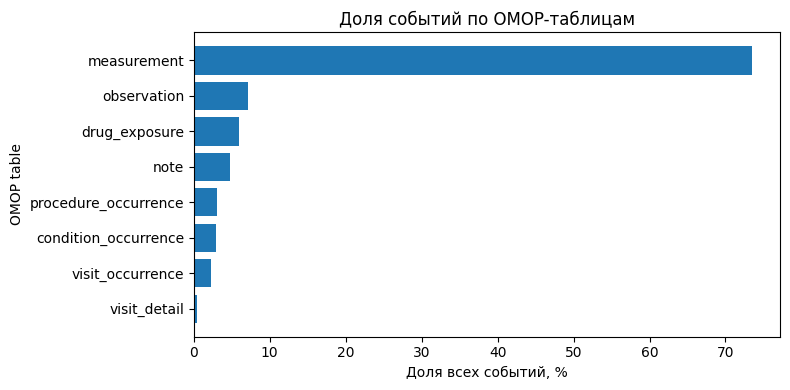

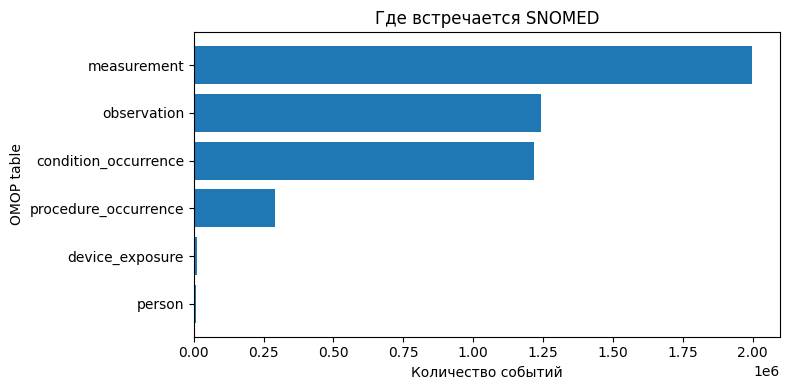

In [8]:
# График 1: из чего состоит event stream.
top_omop = omop_counts.head(8).copy()

plt.figure(figsize=(8, 4))
plt.barh(top_omop["omop_table"][::-1], top_omop["event_share"][::-1] * 100)
plt.title("Доля событий по OMOP-таблицам")
plt.xlabel("Доля всех событий, %")
plt.ylabel("OMOP table")
plt.tight_layout()
plt.show()

# График 2: SNOMED встречается не только в diagnosis layer.
snomed_by_table = (
    family_counts[family_counts["code_family"] == "SNOMED"]
    .sort_values("n_events", ascending=False)
    .head(8)
)

plt.figure(figsize=(8, 4))
plt.barh(snomed_by_table["omop_table"][::-1], snomed_by_table["n_events"][::-1])
plt.title("Где встречается SNOMED")
plt.xlabel("Количество событий")
plt.ylabel("OMOP table")
plt.tight_layout()
plt.show()

## 3. Названия кодов через OMOP/Athena

В локальном `metadata/codes.parquet` descriptions пустые, поэтому для расшифровки кодов используем `CONCEPT.csv` из OMOP/Athena.

Нам важны поля:

- `concept_name` — человекочитаемое название;
- `domain_id` — домен OMOP, например `Condition`;
- `concept_class_id` — тип концепта, например `Disorder` или `Clinical Finding`.

In [9]:
import csv

ATHENA_CONCEPT_CANDIDATES = [
    Path("vocabulary") / "CONCEPT.csv",
    Path("omop_vocab") / "CONCEPT.csv",
    Path("CONCEPT.csv"),
]


def read_athena_concept(path: Path) -> pl.DataFrame:
    """Read OMOP/Athena CONCEPT.csv. Athena export is usually tab-separated."""
    try:
        return pl.read_csv(
            str(path),
            separator="\t",
            has_header=True,
            schema_overrides={
                "concept_id": pl.Utf8,
                "concept_name": pl.Utf8,
                "domain_id": pl.Utf8,
                "vocabulary_id": pl.Utf8,
                "concept_class_id": pl.Utf8,
                "standard_concept": pl.Utf8,
                "concept_code": pl.Utf8,
                "valid_start_date": pl.Utf8,
                "valid_end_date": pl.Utf8,
                "invalid_reason": pl.Utf8,
            },
            null_values=[""],
            quote_char=None,
            encoding="utf8-lossy",
        )
    except Exception as e:
        print("Polars read_csv failed, falling back to pandas. Error:", repr(e))
        concept_pd = pd.read_csv(
            str(path),
            sep="\t",
            dtype=str,
            keep_default_na=False,
            na_values=[""],
            quoting=csv.QUOTE_NONE,
            encoding="utf-8",
            engine="python",
        )
        return pl.from_pandas(concept_pd)


CONCEPT_PATH = next((p for p in ATHENA_CONCEPT_CANDIDATES if p.exists()), None)

if CONCEPT_PATH is not None:
    print("Using Athena CONCEPT.csv:", CONCEPT_PATH)
    concept = read_athena_concept(CONCEPT_PATH)
    concept_small = concept.select([
        "concept_code",
        "concept_name",
        "domain_id",
        "vocabulary_id",
        "concept_class_id",
        "standard_concept",
        "invalid_reason",
    ])
else:
    print("Athena CONCEPT.csv not found. Proceeding without external concept names.")
    concept_small = pl.DataFrame(
        {
            "concept_code": [],
            "concept_name": [],
            "domain_id": [],
            "vocabulary_id": [],
            "concept_class_id": [],
            "standard_concept": [],
            "invalid_reason": [],
        },
        schema={
            "concept_code": pl.Utf8,
            "concept_name": pl.Utf8,
            "domain_id": pl.Utf8,
            "vocabulary_id": pl.Utf8,
            "concept_class_id": pl.Utf8,
            "standard_concept": pl.Utf8,
            "invalid_reason": pl.Utf8,
        },
    )

codes_to_enrich = codes.with_columns([
    pl.col("code").str.split("/").list.get(0).alias("vocabulary_id"),
    pl.col("code").str.split("/").list.get(1).alias("concept_code"),
])

codes_enriched = codes_to_enrich.join(
    concept_small,
    on=["vocabulary_id", "concept_code"],
    how="left",
)

# Empty strings -> nulls.
for col in ["description", "concept_name", "domain_id", "vocabulary_id", "concept_class_id", "standard_concept", "invalid_reason"]:
    if col in codes_enriched.columns:
        codes_enriched = codes_enriched.with_columns(
            pl.when(pl.col(col).is_not_null() & (pl.col(col).str.strip_chars() != ""))
            .then(pl.col(col))
            .otherwise(None)
            .alias(col)
        )

code_meta = (
    codes_enriched
    .with_columns([
        pl.coalesce([pl.col("concept_name"), pl.col("description"), pl.col("code")]).alias("diagnosis_name"),
        pl.col("code").str.split("/").list.get(0).alias("code_family_from_code"),
        pl.col("code").str.split("/").list.get(1).alias("raw_concept_code_from_code"),
    ])
    .select([
        "code", "diagnosis_name", "concept_name", "description",
        "domain_id", "vocabulary_id", "concept_class_id", "standard_concept", "invalid_reason",
        "code_family_from_code", "raw_concept_code_from_code",
    ])
    .unique(subset=["code"], keep="first")
)

coverage_after_enrichment = (
    code_meta
    .with_columns(pl.col("concept_name").is_not_null().alias("has_concept_name"))
    .group_by("vocabulary_id")
    .agg([
        pl.len().alias("n_codes"),
        pl.col("has_concept_name").sum().alias("n_with_concept_name"),
        pl.col("has_concept_name").mean().alias("concept_name_coverage"),
    ])
    .sort("n_codes", descending=True)
    .to_pandas()
)

display_and_save(
    coverage_after_enrichment,
    RESULTS_DIR / "code_name_coverage_after_athena.csv",
    head=12,
)

# Короткий sanity check: examples after enrichment.
sanity_examples = code_meta.head(8).to_pandas()
sanity_examples = add_russian_diagnosis_names(sanity_examples)

display(
    sanity_examples[
        [
            c for c in [
                "code",
                "diagnosis_name",
                "diagnosis_name_ru",
                "domain_id",
                "concept_class_id",
            ]
            if c in sanity_examples.columns
        ]
    ]
)

Using Athena CONCEPT.csv: vocabulary/CONCEPT.csv
Saved: ehrshot_copy_forwarding_audit/code_name_coverage_after_athena.csv
Showing first 12 rows out of 21


,vocabulary_id,n_codes,n_with_concept_name,concept_name_coverage
0,SNOMED,11598,11598,1.00000
1,RxNorm,5433,5433,1.00000
2,CPT4,4675,0,0.00000
3,LOINC,3946,3946,1.00000
4,ICD10PCS,3669,3669,1.00000
5,ICD9Proc,714,714,1.00000
6,RxNorm Extension,422,422,1.00000
7,CARE_SITE,386,0,0.00000
8,ICDO3,162,95,0.58642
9,Cancer Modifier,129,0,0.00000


,code,diagnosis_name,diagnosis_name_ru,domain_id,concept_class_id
0,RxNorm/598,alprostadil,NaN,Drug,Ingredient
1,ICD10PCS/6A550Z3,"Pheresis of Plasma, Single",NaN,Procedure,ICD10PCS
2,RxNorm/311376,lorazepam 2 MG/ML Oral Solution,NaN,Drug,Clinical Drug
3,RxNorm/311678,metronidazole 7.5 MG/ML Topical Cream,NaN,Drug,Clinical Drug
4,CPT4/27427,CPT4/27427,NaN,None,None
5,SNOMED/714151003,Environmental tobacco smoke exposure,NaN,Observation,Observable Entity
6,CPT4/78018,CPT4/78018,NaN,None,None
7,ICD10PCS/0X9J0ZZ,"Drainage of Right Hand, Open Approach",NaN,Procedure,ICD10PCS


### Краткий вывод

- В `codes.parquet` локальные descriptions пустые, поэтому без Athena коды плохо читаются.
- Через Athena подтягиваются `concept_name`, `domain_id`, `concept_class_id`.
- Для diagnosis audit это критично: теперь top-коды можно читать как медицинские понятия, а не только как `SNOMED/...`.
- Athena не говорит, что диагноз хронический. Хроническость ниже определяем по поведению кода во времени.

## 4. Диагнозы и chronic-like кандидаты

Работаем только с `condition_occurrence`.

Идея chronic-like audit простая: если код диагноза часто повторяется у одного пациента в разные дни и тянется на месяцы/годы, он ведет себя как долгосрочное состояние.

Это не клинически подтвержденная разметка хронических заболеваний, а data-driven proxy.

In [10]:
diag_lf = (
    events_lf
    .filter(diagnosis_like_expr())
    .with_columns([
        code_family_expr(),
        pl.col("time").dt.date().alias("event_date"),
    ])
    .join(code_meta.lazy(), on="code", how="left")
)

diag_scope_check = (
    diag_lf
    .select([
        pl.len().alias("n_condition_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
        pl.col("code").n_unique().alias("n_codes"),
        pl.col("concept_name").is_not_null().mean().alias("concept_name_coverage"),
        (pl.col("domain_id") == "Condition").mean().alias("condition_domain_share"),
        (pl.col("concept_class_id") == "Disorder").mean().alias("disorder_class_share"),
        (pl.col("concept_class_id") == "Clinical Finding").mean().alias("clinical_finding_class_share"),
    ])
    .collect()
    .to_pandas()
)

display_and_save(diag_scope_check, RESULTS_DIR / "diagnosis_scope_check_with_athena.csv")

subject_diag_stats = (
    diag_lf
    .group_by("subject_id")
    .agg([
        pl.len().alias("n_diag_events"),
        pl.col("code").n_unique().alias("n_unique_diag_codes"),
        pl.col("event_date").n_unique().alias("n_diag_event_days"),
        pl.col("time").min().alias("first_diag_time"),
        pl.col("time").max().alias("last_diag_time"),
    ])
    .with_columns([
        (pl.col("last_diag_time") - pl.col("first_diag_time")).dt.total_days().alias("diag_span_days"),
        (pl.col("n_diag_events") - pl.col("n_unique_diag_codes")).alias("n_repeated_diag_events_over_first"),
        (pl.col("n_diag_events") / pl.col("n_unique_diag_codes")).alias("diag_events_per_unique_code"),
    ])
    .collect()
    .to_pandas()
)

subject_diag_summary = (
    subject_diag_stats[[
        "n_diag_events", "n_unique_diag_codes", "n_diag_event_days", "diag_span_days",
        "n_repeated_diag_events_over_first", "diag_events_per_unique_code",
    ]]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)

display_and_save(subject_diag_summary, RESULTS_DIR / "subject_diagnosis_summary.csv", head=100)

Saved: ehrshot_copy_forwarding_audit/diagnosis_scope_check_with_athena.csv


,n_condition_events,n_subjects,n_codes,concept_name_coverage,condition_domain_share,disorder_class_share,clinical_finding_class_share
0,1219611,6144,8759,0.999894,0.934603,0.778967,0.220499


Saved: ehrshot_copy_forwarding_audit/subject_diagnosis_summary.csv


,metric,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
0,n_diag_events,6144.0,198.504395,350.634633,1.0,8.000000,26.000000,74.0,211.00,503.000000,810.000000,1707.140000,4844.000000
1,n_unique_diag_codes,6144.0,47.968424,53.326736,1.0,5.000000,14.000000,30.0,62.00,112.000000,153.000000,256.570000,524.000000
2,n_diag_event_days,6144.0,63.672526,100.937177,1.0,3.000000,8.000000,26.0,73.00,167.000000,267.000000,500.850000,1058.000000
3,diag_span_days,6144.0,1967.933594,1934.140068,0.0,13.000000,309.000000,1398.0,3247.00,4784.700000,5386.700000,7241.830000,21134.000000
4,n_repeated_diag_events_over_first,6144.0,150.535970,303.440681,0.0,1.000000,9.000000,41.0,152.25,398.000000,664.850000,1457.570000,4320.000000
5,diag_events_per_unique_code,6144.0,3.068671,2.083432,1.0,1.153846,1.619048,2.5,3.92,5.632195,6.952113,10.035614,32.866667


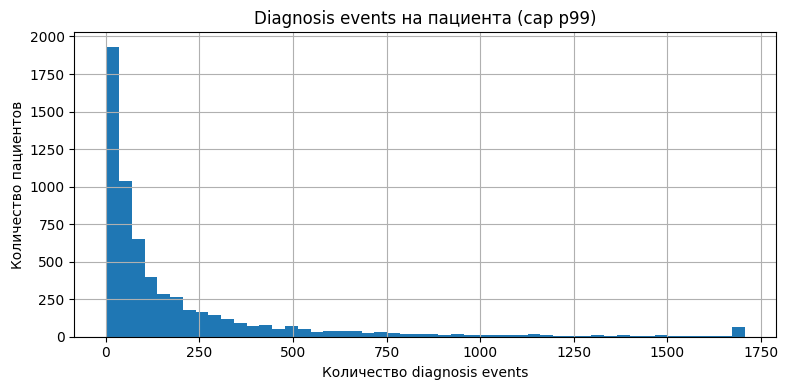

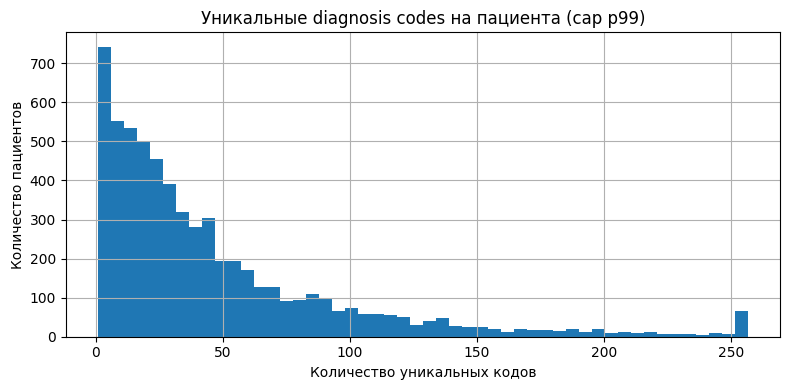

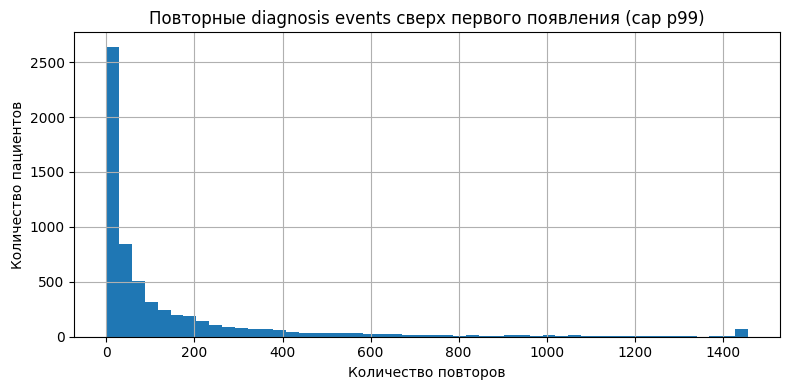

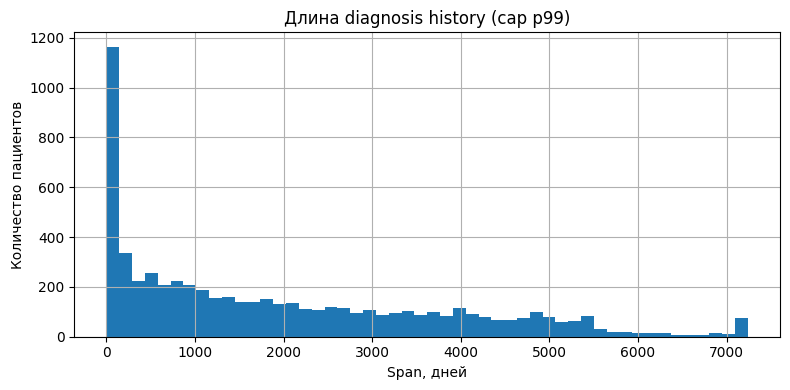

In [11]:
# Наглядно: как распределены diagnosis events по пациентам.
plot_specs = [
    ("n_diag_events", "Diagnosis events на пациента", "Количество diagnosis events"),
    ("n_unique_diag_codes", "Уникальные diagnosis codes на пациента", "Количество уникальных кодов"),
    ("n_repeated_diag_events_over_first", "Повторные diagnosis events сверх первого появления", "Количество повторов"),
    ("diag_span_days", "Длина diagnosis history", "Span, дней"),
]

for col, title, xlabel in plot_specs:
    values = subject_diag_stats[col].dropna()
    cap = values.quantile(0.99)

    plt.figure(figsize=(8, 4))
    values.clip(upper=cap).hist(bins=50)
    plt.title(f"{title} (cap p99)")
    plt.xlabel(xlabel)
    plt.ylabel("Количество пациентов")
    plt.tight_layout()
    plt.show()

In [12]:
diag_patient_code = (
    diag_lf
    .group_by(["subject_id", "code"])
    .agg([
        pl.len().alias("n_events_for_code"),
        pl.col("event_date").n_unique().alias("n_days_with_code"),
        pl.col("time").min().alias("first_code_time"),
        pl.col("time").max().alias("last_code_time"),
        pl.col("diagnosis_name").first().alias("diagnosis_name"),
        pl.col("domain_id").first().alias("domain_id"),
        pl.col("vocabulary_id").first().alias("vocabulary_id"),
        pl.col("concept_class_id").first().alias("concept_class_id"),
        pl.col("standard_concept").first().alias("standard_concept"),
        pl.col("invalid_reason").first().alias("invalid_reason"),
    ])
    .with_columns([
        (pl.col("last_code_time") - pl.col("first_code_time")).dt.total_days().alias("code_span_days"),
        (pl.col("n_events_for_code") - 1).alias("n_duplicate_events_for_code"),
        (pl.col("n_days_with_code") - 1).alias("n_duplicate_days_for_code"),
        (pl.col("n_events_for_code") >= 2).alias("is_repeated_event"),
        (pl.col("n_days_with_code") >= 2).alias("is_repeated_across_days"),
    ])
    .with_columns([
        ((pl.col("n_days_with_code") >= 2) & (pl.col("code_span_days") >= 30)).alias("is_persistent_30d"),
        ((pl.col("n_days_with_code") >= 2) & (pl.col("code_span_days") >= 90)).alias("is_persistent_90d"),
        ((pl.col("n_days_with_code") >= 2) & (pl.col("code_span_days") >= 180)).alias("is_persistent_180d"),
        ((pl.col("n_days_with_code") >= 2) & (pl.col("code_span_days") >= 365)).alias("is_persistent_365d"),
    ])
    .collect()
)

display(diag_patient_code.head(10).to_pandas())
diag_patient_code.write_csv(RESULTS_DIR / "diagnosis_patient_code_persistence.csv")

,subject_id,code,n_events_for_code,n_days_with_code,first_code_time,last_code_time,diagnosis_name,domain_id,vocabulary_id,concept_class_id,standard_concept,invalid_reason,code_span_days,n_duplicate_events_for_code,n_duplicate_days_for_code,is_repeated_event,is_repeated_across_days,is_persistent_30d,is_persistent_90d,is_persistent_180d,is_persistent_365d
0,115972798,SNOMED/139394000,1,1,2016-10-13 14:41:00,2016-10-13 14:41:00,Nocturia,Condition,SNOMED,Clinical Finding,S,None,0,0,0,False,False,False,False,False,False
1,115973465,SNOMED/49650001,3,3,2017-10-07 13:22:00,2019-09-20 16:12:00,Dysuria,Condition,SNOMED,Clinical Finding,S,None,713,2,2,True,True,True,True,True,True
2,115971876,SNOMED/240134003,2,2,2014-04-23 23:59:00,2014-11-04 12:50:00,Disorder of bone and articular cartilage,Condition,SNOMED,Disorder,S,None,194,1,1,True,True,True,True,True,False
3,115969583,SNOMED/94348003,1,1,2011-04-21 15:08:00,2011-04-21 15:08:00,Metastatic malignant neoplasm to intra-abdomin...,Condition,SNOMED,Disorder,None,None,0,0,0,False,False,False,False,False,False
4,115970521,SNOMED/111287006,2,2,2020-08-15 18:57:00,2020-09-09 17:25:00,Tricuspid valve regurgitation,Condition,SNOMED,Disorder,S,None,24,1,1,True,True,False,False,False,False
5,115967754,SNOMED/7678002,5,5,2016-09-22 23:59:00,2016-10-18 23:59:00,Cytomegaloviral pneumonia,Condition,SNOMED,Disorder,S,None,26,4,4,True,True,False,False,False,False
6,115967448,SNOMED/42343007,9,9,2009-07-09 23:59:00,2015-08-15 13:17:00,Congestive heart failure,Condition,SNOMED,Disorder,S,None,2227,8,8,True,True,True,True,True,True
7,115970800,SNOMED/359557001,3,3,2022-04-16 23:59:00,2022-09-03 23:59:00,Disorder of artery,Condition,SNOMED,Disorder,S,None,140,2,2,True,True,True,True,False,False
8,115970414,SNOMED/128189008,1,1,2019-03-23 23:59:00,2019-03-23 23:59:00,Mononeuropathy,Condition,SNOMED,Disorder,S,None,0,0,0,False,False,False,False,False,False
9,115971006,SNOMED/16294009,1,1,2018-06-10 19:45:00,2018-06-10 19:45:00,Splenomegaly,Condition,SNOMED,Disorder,S,None,0,0,0,False,False,False,False,False,False


### Правила выделения chronic-like diagnosis candidates

На этом шаге мы агрегируем diagnosis events с уровня `patient-code` на уровень самого diagnosis code. Цель — найти коды, которые в данных ведут себя как долгосрочные / хронические состояния.

Мы не используем готовую клиническую разметку хронических заболеваний. Вместо этого задаем эмпирические правила на основе longitudinal behavior:

* код должен встречаться у достаточного числа пациентов;
* код должен повторяться у пациента в разные даты, а не только несколько раз в один день;
* между первым и последним появлением кода должен быть достаточно длинный span;
* отдельно учитываем persistence на горизонтах 90, 180 и 365 дней.

Для каждого diagnosis code считаются доли пациентов, у которых код повторялся в разные дни (`repeat_day_subject_share`) и сохранялся на длинных горизонтах (`persistent_90d_subject_share`, `persistent_180d_subject_share`, `persistent_365d_subject_share`). Также считаются `p75_span_days` и `p90_span_days`, чтобы понять, насколько длинный временной хвост есть у этого кода.

Далее коды делятся на группы:

| Группа                               | Правило                                                                                                                                  | Интерпретация                                               |
| ------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------- |
| `strong_chronic_like`                | код есть минимум у 50 пациентов, повторяется в разные дни минимум у 50% из них, и имеет годовой persistence или `p75_span_days >= 365`   | сильный кандидат на хроническое / persistent состояние      |
| `possible_chronic_like`              | код есть минимум у 30 пациентов, повторяется в разные дни минимум у 30% из них, и имеет persistence 180+ дней или `p75_span_days >= 180` | возможный chronic-like кандидат                             |
| `repeated_short_span`                | код есть минимум у 20 пациентов, часто повторяется, но `p75_span_days <= 90`                                                             | повторяющийся episode-level код, не обязательно хронический |
| `not_chronic_like_by_empirical_rule` | все остальные коды                                                                                                                       | не выглядит chronic-like по выбранным правилам              |

Дополнительно считается `empirical_persistence_score`. Он нужен только для ранжирования кодов внутри таблицы: выше оказываются коды, которые чаще повторяются, чаще сохраняются на 90/180/365 дней и имеют более длинный `p90_span_days`.

Важно: группа `chronic_like` не означает клинически подтвержденный хронический диагноз. Это эмпирическая proxy-разметка, которая показывает, какие diagnosis codes ведут себя как долгосрочные состояния в EHR.

In [13]:
n_diag_subjects = diag_patient_code.select(pl.col("subject_id").n_unique()).item()

code_persistence_stats = (
    diag_patient_code
    .group_by("code")
    .agg([
        pl.col("diagnosis_name").first().alias("diagnosis_name"),
        pl.col("domain_id").first().alias("domain_id"),
        pl.col("vocabulary_id").first().alias("vocabulary_id"),
        pl.col("concept_class_id").first().alias("concept_class_id"),
        pl.col("standard_concept").first().alias("standard_concept"),
        pl.col("invalid_reason").first().alias("invalid_reason"),
        pl.col("subject_id").n_unique().alias("n_subjects_with_code"),
        pl.col("n_events_for_code").sum().alias("n_events"),
        pl.col("n_duplicate_events_for_code").sum().alias("n_duplicate_events_over_first"),
        pl.col("n_duplicate_days_for_code").sum().alias("n_duplicate_days_over_first"),
        pl.col("n_events_for_code").median().alias("median_events_per_subject"),
        pl.col("n_events_for_code").quantile(0.90).alias("p90_events_per_subject"),
        pl.col("n_days_with_code").median().alias("median_days_with_code"),
        pl.col("n_days_with_code").quantile(0.90).alias("p90_days_with_code"),
        pl.col("code_span_days").median().alias("median_span_days"),
        pl.col("code_span_days").quantile(0.75).alias("p75_span_days"),
        pl.col("code_span_days").quantile(0.90).alias("p90_span_days"),
        pl.col("is_repeated_across_days").mean().alias("repeat_day_subject_share"),
        pl.col("is_persistent_90d").mean().alias("persistent_90d_subject_share"),
        pl.col("is_persistent_180d").mean().alias("persistent_180d_subject_share"),
        pl.col("is_persistent_365d").mean().alias("persistent_365d_subject_share"),
    ])
    .with_columns([
        (pl.col("n_subjects_with_code") / pl.lit(n_diag_subjects)).alias("subject_prevalence"),
        (pl.col("n_duplicate_events_over_first") / pl.col("n_events")).alias("duplicate_event_share"),
    ])
    .with_columns([
        (
            0.20 * pl.col("repeat_day_subject_share")
            + 0.20 * pl.col("persistent_90d_subject_share")
            + 0.25 * pl.col("persistent_180d_subject_share")
            + 0.25 * pl.col("persistent_365d_subject_share")
            + 0.10 * (pl.col("p90_span_days") / (pl.col("p90_span_days") + 365))
        ).alias("empirical_persistence_score")
    ])
    .with_columns([
        pl.when(
            (pl.col("n_subjects_with_code") >= 50)
            & (pl.col("repeat_day_subject_share") >= 0.50)
            & ((pl.col("persistent_365d_subject_share") >= 0.10) | (pl.col("p75_span_days") >= 365))
        )
        .then(pl.lit("strong_chronic_like"))
        .when(
            (pl.col("n_subjects_with_code") >= 30)
            & (pl.col("repeat_day_subject_share") >= 0.30)
            & ((pl.col("persistent_180d_subject_share") >= 0.15) | (pl.col("p75_span_days") >= 180))
        )
        .then(pl.lit("possible_chronic_like"))
        .when(
            (pl.col("n_subjects_with_code") >= 20)
            & (pl.col("repeat_day_subject_share") >= 0.30)
            & (pl.col("p75_span_days") <= 90)
        )
        .then(pl.lit("repeated_short_span"))
        .otherwise(pl.lit("not_chronic_like_by_empirical_rule"))
        .alias("empirical_chronic_like_group")
    ])
    .sort(["empirical_persistence_score", "n_subjects_with_code"], descending=True)
)

code_persistence_pd = code_persistence_stats.to_pandas()
display_and_save(code_persistence_pd, RESULTS_DIR / "diagnosis_code_empirical_chronic_like_stats.csv", head=100)

Saved: ehrshot_copy_forwarding_audit/diagnosis_code_empirical_chronic_like_stats.csv
Showing first 100 rows out of 8759


,code,diagnosis_name,domain_id,vocabulary_id,concept_class_id,standard_concept,invalid_reason,n_subjects_with_code,n_events,n_duplicate_events_over_first,n_duplicate_days_over_first,median_events_per_subject,p90_events_per_subject,median_days_with_code,p90_days_with_code,median_span_days,p75_span_days,p90_span_days,repeat_day_subject_share,persistent_90d_subject_share,persistent_180d_subject_share,persistent_365d_subject_share,subject_prevalence,duplicate_event_share,empirical_persistence_score,empirical_chronic_like_group
0,SNOMED/37151006,Erythromelalgia,Condition,SNOMED,Disorder,S,None,1,404,403,403,404.0,404.0,404.0,404.0,5223.0,5223.0,5223.0,1.0,1.0,1.0,1.0,0.000163,0.997525,0.993468,not_chronic_like_by_empirical_rule
1,SNOMED/28293008,Hereditary factor VIII deficiency disease,Condition,SNOMED,Disorder,S,None,2,146,144,144,73.0,136.0,73.0,136.0,3430.5,5060.0,5060.0,1.0,1.0,1.0,1.0,0.000326,0.986301,0.993272,not_chronic_like_by_empirical_rule
2,SNOMED/78769001,Disseminated chorioretinitis,Condition,SNOMED,Disorder,S,None,1,9,8,8,9.0,9.0,9.0,9.0,4991.0,4991.0,4991.0,1.0,1.0,1.0,1.0,0.000163,0.888889,0.993185,not_chronic_like_by_empirical_rule
3,SNOMED/201261003,Urticaria caused by cold and heat,Condition,SNOMED,Disorder,S,None,1,3,2,2,3.0,3.0,3.0,3.0,4768.0,4768.0,4768.0,1.0,1.0,1.0,1.0,0.000163,0.666667,0.992889,not_chronic_like_by_empirical_rule
4,SNOMED/707742001,Bartter syndrome,Condition,SNOMED,Disorder,S,None,1,17,16,16,17.0,17.0,17.0,17.0,4405.0,4405.0,4405.0,1.0,1.0,1.0,1.0,0.000163,0.941176,0.992348,not_chronic_like_by_empirical_rule
5,SNOMED/40527005,Idiopathic pulmonary hemosiderosis,Condition,SNOMED,Disorder,S,None,1,4,3,3,4.0,4.0,4.0,4.0,4165.0,4165.0,4165.0,1.0,1.0,1.0,1.0,0.000163,0.750000,0.991943,not_chronic_like_by_empirical_rule
6,SNOMED/54184008,Senile reticular retinal degeneration,Condition,SNOMED,Disorder,S,None,4,39,35,35,9.0,17.0,9.0,17.0,1503.5,2102.0,3194.0,1.0,1.0,1.0,1.0,0.000651,0.897436,0.989744,not_chronic_like_by_empirical_rule
7,SNOMED/417048006,Sickle cell-thalassemia disease without crisis,Condition,SNOMED,Disorder,S,None,2,140,138,138,70.0,137.0,70.0,137.0,1798.5,3138.0,3138.0,1.0,1.0,1.0,1.0,0.000326,0.985714,0.989580,not_chronic_like_by_empirical_rule
8,SNOMED/82562007,Osteochondritis dissecans,Condition,SNOMED,Disorder,S,None,2,13,11,11,6.5,8.0,6.5,8.0,1785.0,3136.0,3136.0,1.0,1.0,1.0,1.0,0.000326,0.846154,0.989574,not_chronic_like_by_empirical_rule
9,SNOMED/61758007,Exstrophy of urinary bladder sequence,Condition,SNOMED,Disorder,S,None,1,3,2,2,3.0,3.0,3.0,3.0,3113.0,3113.0,3113.0,1.0,1.0,1.0,1.0,0.000163,0.666667,0.989505,not_chronic_like_by_empirical_rule


Saved: ehrshot_copy_forwarding_audit/empirical_chronic_like_group_summary.csv


,empirical_chronic_like_group,n_codes,median_subjects_per_code,median_duplicate_event_share,median_persistent_365d_subject_share,median_p90_span_days
0,not_chronic_like_by_empirical_rule,7231,3.0,0.333333,0.000000,23.0
1,possible_chronic_like,667,66.0,0.636888,0.183673,841.0
2,strong_chronic_like,444,135.0,0.799102,0.309479,1483.0
3,repeated_short_span,417,36.0,0.530120,0.077720,197.0


Saved: ehrshot_copy_forwarding_audit/top_duplicate_diagnosis_codes_compact_ru.csv


,code,diagnosis_dataset_to_ru,n_subjects_with_code,n_events,n_duplicate_events_over_first,duplicate_event_share,median_span_days,p90_span_days,empirical_chronic_like_group
0,SNOMED/59621000,Essential hypertension — эссенциальная артериа...,2855,29654,26799,0.903723,496.0,3393.0,strong_chronic_like
1,SNOMED/55822004,Hyperlipidemia — гиперлипидемия,2398,18212,15814,0.868329,333.5,3347.0,strong_chronic_like
2,SNOMED/313436004,Type 2 diabetes mellitus without complication ...,1189,12877,11688,0.907665,310.0,3171.0,strong_chronic_like
3,SNOMED/737295003,Transplanted kidney present — наличие транспла...,130,11176,11046,0.988368,1597.0,4354.0,strong_chronic_like
4,SNOMED/737296002,Transplanted lung present — наличие трансплант...,86,10923,10837,0.992127,398.0,3461.0,strong_chronic_like
5,SNOMED/233932001,Cardiac transplant disorder — состояние / осло...,64,8347,8283,0.992333,1369.5,4707.0,strong_chronic_like
6,SNOMED/46177005,End-stage renal disease — терминальная стадия ...,284,8188,7904,0.965315,520.5,3627.0,strong_chronic_like
7,SNOMED/49436004,Atrial fibrillation — фибрилляция предсердий,856,8523,7667,0.899566,111.0,2439.0,strong_chronic_like
8,SNOMED/739024006,Transplanted heart present — наличие трансплан...,87,7732,7645,0.988748,522.0,3909.0,strong_chronic_like
9,SNOMED/267036007,Dyspnea — одышка,1516,8716,7200,0.826067,61.0,2096.0,strong_chronic_like


Strong chronic-like codes: 444
Possible chronic-like codes: 667


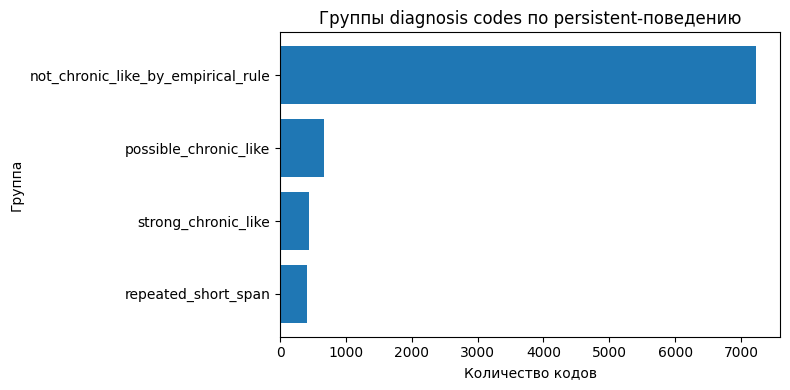

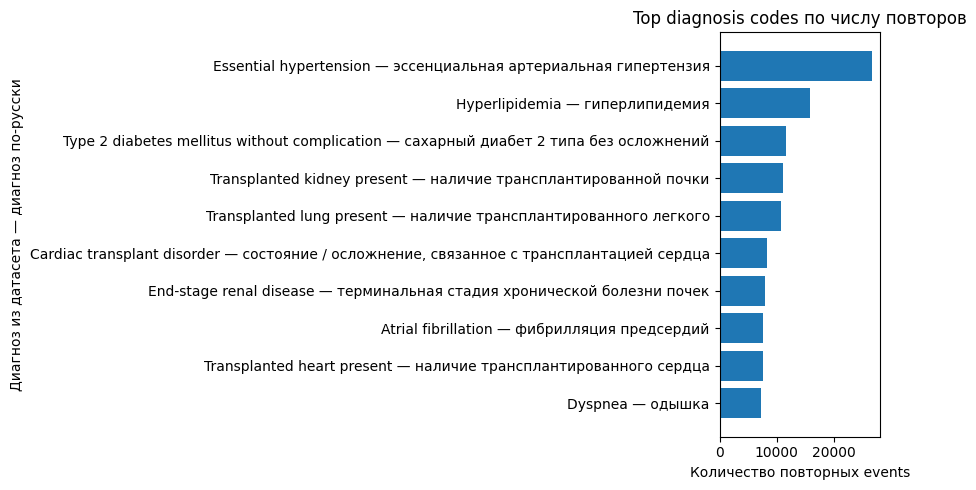

In [14]:
strong_chronic_like = (
    code_persistence_stats
    .filter(pl.col("empirical_chronic_like_group") == "strong_chronic_like")
    .sort(["empirical_persistence_score", "n_subjects_with_code"], descending=True)
)

possible_chronic_like = (
    code_persistence_stats
    .filter(pl.col("empirical_chronic_like_group") == "possible_chronic_like")
    .sort(["empirical_persistence_score", "n_subjects_with_code"], descending=True)
)

top_duplicate_diagnosis_codes = (
    code_persistence_stats
    .sort(["n_duplicate_events_over_first", "duplicate_event_share"], descending=True)
)

chronic_group_summary = (
    code_persistence_stats
    .group_by("empirical_chronic_like_group")
    .agg([
        pl.len().alias("n_codes"),
        pl.col("n_subjects_with_code").median().alias("median_subjects_per_code"),
        pl.col("duplicate_event_share").median().alias("median_duplicate_event_share"),
        pl.col("persistent_365d_subject_share").median().alias("median_persistent_365d_subject_share"),
        pl.col("p90_span_days").median().alias("median_p90_span_days"),
    ])
    .sort("n_codes", descending=True)
    .to_pandas()
)

display_and_save(chronic_group_summary, RESULTS_DIR / "empirical_chronic_like_group_summary.csv", head=None)

top_duplicate_compact = attach_code_descriptions(top_duplicate_diagnosis_codes.head(25).to_pandas())
top_duplicate_compact = compact_diagnosis_table(
    top_duplicate_compact,
    [
        "code",
        "diagnosis_dataset_to_ru",
        "domain_id",
        "concept_class_id",
        "n_subjects_with_code",
        "n_events",
        "n_duplicate_events_over_first",
        "duplicate_event_share",
        "median_span_days",
        "p90_span_days",
        "empirical_chronic_like_group",
    ],
    n=12,
)

display_and_save(
    top_duplicate_compact,
    RESULTS_DIR / "top_duplicate_diagnosis_codes_compact_ru.csv",
    head=None,
)

# Полные таблицы сохраняем отдельно, в ноутбуке не показываем 100 строк.
strong_chronic_like.write_csv(RESULTS_DIR / "strong_empirical_chronic_like_diagnosis_codes.csv")
possible_chronic_like.write_csv(RESULTS_DIR / "possible_empirical_chronic_like_diagnosis_codes.csv")
top_duplicate_diagnosis_codes.write_csv(RESULTS_DIR / "top_duplicate_diagnosis_codes.csv")

print("Strong chronic-like codes:", strong_chronic_like.height)
print("Possible chronic-like codes:", possible_chronic_like.height)

# График: сколько кодов попало в каждую группу.
plt.figure(figsize=(8, 4))
plt.barh(chronic_group_summary["empirical_chronic_like_group"][::-1], chronic_group_summary["n_codes"][::-1])
plt.title("Группы diagnosis codes по persistent-поведению")
plt.xlabel("Количество кодов")
plt.ylabel("Группа")
plt.tight_layout()
plt.show()

# График: какие диагнозы сильнее всего раздувают diagnosis layer.
plot_df = top_duplicate_compact.iloc[:10].copy()
plt.figure(figsize=(9, 5))
plt.barh(plot_df["diagnosis_dataset_to_ru"][::-1], plot_df["n_duplicate_events_over_first"][::-1])
plt.title("Top diagnosis codes по числу повторов")
plt.xlabel("Количество повторных events")
plt.ylabel("Диагноз из датасета — диагноз по-русски")
plt.tight_layout()
plt.show()

### Краткий вывод

- В `condition_occurrence` найдено **1.22 млн diagnosis-like событий** для **6,144 пациентов**.
- Почти все diagnosis codes получили названия через Athena.
- У медианного пациента: **74 diagnosis events**, **30 уникальных diagnosis codes**, **41 повтор сверх первого появления**.
- Chronic-like кандидаты выделяются не по словарю, а по persistence во времени:
  - код повторяется в разные дни;
  - span между первым и последним появлением достаточно длинный;
  - код встречается у достаточного числа пациентов.
- Самые сильные драйверы повторов — понятные долгосрочные состояния:  
  `Essential hypertension — эссенциальная артериальная гипертензия`,  
  `Hyperlipidemia — гиперлипидемия`,  
  `Type 2 diabetes mellitus without complication — сахарный диабет 2 типа без осложнений`,  
  `End-stage renal disease — терминальная стадия хронической болезни почек`.

Важно: это **empirical chronic-like candidates**, а не официальная клиническая разметка хронических болезней.

Часть persistent-like кодов не является хроническими заболеваниями в строгом клиническом смысле. Например, `Transplanted kidney present` означает наличие трансплантированной почки, то есть persistent clinical status. Такие коды всё равно важны для compression audit, потому что они могут регулярно переноситься в истории пациента и раздувать sequence, но в отчете их лучше называть persistent status/finding concepts, а не chronic diseases.

## 5. Overlap диагнозов между соседними reconstructed visits

В MEDS нет прямого `visit_id` для каждой строки `condition_occurrence`. Поэтому строим приближение:

```text
visit anchor = subject_id + time из visit_occurrence
```

В этой версии используем только `Visit/...` коды внутри `visit_occurrence`, чтобы не смешивать визиты со служебными OMOP metadata-кодами.

Дальше привязываем диагноз к ближайшему предыдущему visit anchor и считаем Jaccard overlap между соседними визитами. Высокий overlap — это proxy для repeated diagnosis documentation / copy-forwarding / persistent problem list.

In [15]:
def attach_code_names_local(df: pd.DataFrame) -> pd.DataFrame:
    if "code" not in df.columns:
        return df
    return attach_code_descriptions(df, code_col="code")


visit_events_lf = (
    events_lf
    .filter(pl.col("omop_table") == "visit_occurrence")
    .filter(pl.col("code").str.starts_with("Visit/"))
    .with_columns([
        code_family_expr(),
        pl.col("time").dt.date().alias("visit_date"),
    ])
)

visit_code_counts = (
    visit_events_lf
    .group_by(["code_family", "code"])
    .agg([
        pl.len().alias("n_events"),
        pl.col("subject_id").n_unique().alias("n_subjects"),
    ])
    .sort("n_events", descending=True)
    .collect()
    .to_pandas()
)

visit_code_counts = attach_code_names_local(visit_code_counts)
display_and_save(visit_code_counts, RESULTS_DIR / "visit_occurrence_code_counts.csv", head=8)

Saved: ehrshot_copy_forwarding_audit/visit_occurrence_code_counts.csv


,code_family,code,n_events,n_subjects,diagnosis_name,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,invalid_reason,diagnosis_name_ru,diagnosis_dataset_to_ru
0,Visit,Visit/OP,184318,5408,Outpatient Visit,Outpatient Visit,Visit,Visit,Visit,S,None,NaN,Outpatient Visit — перевод не задан
1,Visit,Visit/OMOP4822458,132597,4914,Office Visit,Office Visit,Visit,Visit,Visit,S,None,NaN,Office Visit — перевод не задан
2,Visit,Visit/IP,35748,4322,Inpatient Visit,Inpatient Visit,Visit,Visit,Visit,S,None,NaN,Inpatient Visit — перевод не задан
3,Visit,Visit/OMOP4822461,13240,2111,Laboratory Visit,Laboratory Visit,Visit,Visit,Visit,S,None,NaN,Laboratory Visit — перевод не задан
4,Visit,Visit/ER,9553,2316,Emergency Room Visit,Emergency Room Visit,Visit,Visit,Visit,S,None,NaN,Emergency Room Visit — перевод не задан
5,Visit,Visit/ERIP,4861,1867,Emergency Room and Inpatient Visit,Emergency Room and Inpatient Visit,Visit,Visit,Visit,S,None,NaN,Emergency Room and Inpatient Visit — перевод н...


In [16]:
visit_anchors = (
    visit_events_lf
    .group_by(["subject_id", "time"])
    .agg([
        pl.col("code").unique().sort().alias("visit_codes"),
        pl.col("code_family").unique().sort().alias("visit_code_families"),
        pl.len().alias("n_visit_rows_at_time"),
    ])
    .sort(["subject_id", "time"])
    .with_columns([
        (pl.col("time").cum_count().over("subject_id") - 1).alias("visit_idx"),
        pl.col("time").shift(-1).over("subject_id").alias("next_visit_time"),
    ])
    .collect()
)

visit_anchor_summary = (
    visit_anchors
    .select([
        pl.len().alias("n_visit_anchors"),
        pl.col("subject_id").n_unique().alias("n_subjects_with_visit_anchors"),
        pl.col("n_visit_rows_at_time").mean().alias("mean_rows_per_visit_anchor"),
        pl.col("n_visit_rows_at_time").median().alias("median_rows_per_visit_anchor"),
        pl.col("n_visit_rows_at_time").quantile(0.90).alias("p90_rows_per_visit_anchor"),
        pl.col("n_visit_rows_at_time").max().alias("max_rows_per_visit_anchor"),
    ])
    .to_pandas()
)

display_and_save(visit_anchor_summary, RESULTS_DIR / "visit_anchor_summary.csv")
display(visit_anchors.select(["subject_id", "time", "visit_idx", "n_visit_rows_at_time"]).head(8).to_pandas())

Saved: ehrshot_copy_forwarding_audit/visit_anchor_summary.csv


,n_visit_anchors,n_subjects_with_visit_anchors,mean_rows_per_visit_anchor,median_rows_per_visit_anchor,p90_rows_per_visit_anchor,max_rows_per_visit_anchor
0,364418,6191,1.043628,1.0,1.0,26


,subject_id,time,visit_idx,n_visit_rows_at_time
0,115967095,2008-10-07 23:56:00,0,1
1,115967095,2008-10-11 19:43:00,1,1
2,115967096,2009-02-07 14:35:00,0,1
3,115967096,2009-07-26 11:45:00,1,1
4,115967096,2010-06-27 13:48:00,2,1
5,115967096,2010-06-27 15:30:00,3,1
6,115967096,2010-07-04 10:47:00,4,1
7,115967096,2010-08-21 11:50:00,5,1


In [17]:
diagnosis_for_join_lf = (
    diag_lf
    .select(["subject_id", "time", "event_date", "code", "diagnosis_name", "domain_id", "concept_class_id"])
    .sort(["subject_id", "time"])
)

visit_anchors_for_join_lf = (
    visit_anchors
    .lazy()
    .rename({"time": "visit_time"})
    .select(["subject_id", "visit_time", "visit_idx", "next_visit_time", "visit_codes", "visit_code_families", "n_visit_rows_at_time"])
    .sort(["subject_id", "visit_time"])
)

diagnosis_with_visit = (
    diagnosis_for_join_lf
    .join_asof(
        visit_anchors_for_join_lf,
        left_on="time",
        right_on="visit_time",
        by="subject_id",
        strategy="backward",
    )
    .with_columns([
        ((pl.col("time") - pl.col("visit_time")).dt.total_hours() / 24).alias("days_since_visit_anchor"),
        ((pl.col("next_visit_time") - pl.col("time")).dt.total_hours() / 24).alias("days_until_next_visit_anchor"),
    ])
    .collect()
)

diagnosis_visit_assignment_summary = (
    diagnosis_with_visit
    .select([
        pl.len().alias("n_diagnosis_events"),
        pl.col("visit_idx").is_not_null().sum().alias("n_assigned_to_visit_anchor"),
        pl.col("visit_idx").is_not_null().mean().alias("assigned_share"),
        pl.col("days_since_visit_anchor").median().alias("median_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").quantile(0.75).alias("p75_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").quantile(0.90).alias("p90_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").quantile(0.95).alias("p95_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").max().alias("max_days_since_visit_anchor"),
    ])
    .to_pandas()
)

display_and_save(diagnosis_visit_assignment_summary, RESULTS_DIR / "diagnosis_visit_assignment_summary.csv")
display(diagnosis_with_visit.select(["subject_id", "time", "code", "diagnosis_name", "visit_time", "visit_idx", "days_since_visit_anchor"]).head(8).to_pandas())

Saved: ehrshot_copy_forwarding_audit/diagnosis_visit_assignment_summary.csv


,n_diagnosis_events,n_assigned_to_visit_anchor,assigned_share,median_days_since_visit_anchor,p75_days_since_visit_anchor,p90_days_since_visit_anchor,p95_days_since_visit_anchor,max_days_since_visit_anchor
0,1219611,1208035,0.990508,0.583333,5.083333,24.625,67.583333,5268.0


,subject_id,time,code,diagnosis_name,visit_time,visit_idx,days_since_visit_anchor
0,115967095,2008-10-14 23:59:00,SNOMED/22741003,Noninflammatory disorder of the vagina,2008-10-11 19:43:00,1,3.166667
1,115967095,2008-10-15 10:50:00,SNOMED/22741003,Noninflammatory disorder of the vagina,2008-10-11 19:43:00,1,3.625000
2,115967096,2009-02-07 23:59:00,SNOMED/43064006,Hydronephrosis,2009-02-07 14:35:00,0,0.375000
3,115967096,2009-02-24 23:59:00,SNOMED/43064006,Hydronephrosis,2009-02-07 14:35:00,0,17.375000
4,115967096,2009-07-26 23:59:00,SNOMED/20018005,Occlusion of ureter,2009-07-26 11:45:00,1,0.500000
5,115967096,2010-06-27 23:59:00,SNOMED/43064006,Hydronephrosis,2010-06-27 15:30:00,3,0.333333
6,115967096,2010-07-04 10:15:00,SNOMED/43064006,Hydronephrosis,2010-06-27 15:30:00,3,6.750000
7,115967096,2010-07-04 17:57:00,SNOMED/128073008,Disorder of ureter,2010-07-04 10:47:00,4,0.291667


In [18]:
MAX_DAYS_SINCE_VISIT_ANCHOR = 30

diagnosis_with_visit_strict = diagnosis_with_visit.filter(
    pl.col("visit_idx").is_not_null()
    & (pl.col("days_since_visit_anchor") >= 0)
    & (pl.col("days_since_visit_anchor") <= MAX_DAYS_SINCE_VISIT_ANCHOR)
)

strict_assignment_summary = (
    diagnosis_with_visit_strict
    .select([
        pl.len().alias("n_diagnosis_events_strict"),
        pl.col("subject_id").n_unique().alias("n_subjects_strict"),
        pl.col("code").n_unique().alias("n_codes_strict"),
        pl.col("days_since_visit_anchor").median().alias("median_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").quantile(0.90).alias("p90_days_since_visit_anchor"),
        pl.col("days_since_visit_anchor").max().alias("max_days_since_visit_anchor"),
    ])
    .to_pandas()
)

display_and_save(strict_assignment_summary, RESULTS_DIR / "diagnosis_visit_assignment_strict_summary.csv")

diagnosis_by_visit = (
    diagnosis_with_visit_strict
    .group_by(["subject_id", "visit_idx"])
    .agg([
        pl.col("code").unique().sort().alias("diag_codes"),
        pl.len().alias("n_diag_events_in_visit"),
        pl.col("code").n_unique().alias("n_unique_diag_codes_in_visit"),
        pl.col("visit_time").min().alias("visit_time"),
        pl.col("next_visit_time").min().alias("next_visit_time"),
        pl.col("days_since_visit_anchor").median().alias("median_days_since_visit_anchor"),
    ])
    .sort(["subject_id", "visit_idx"])
    .to_pandas()
)

print("diagnosis_by_visit shape:", diagnosis_by_visit.shape)
display(diagnosis_by_visit[["subject_id", "visit_idx", "visit_time", "n_diag_events_in_visit", "n_unique_diag_codes_in_visit"]].head(8))

Saved: ehrshot_copy_forwarding_audit/diagnosis_visit_assignment_strict_summary.csv


,n_diagnosis_events_strict,n_subjects_strict,n_codes_strict,median_days_since_visit_anchor,p90_days_since_visit_anchor,max_days_since_visit_anchor
0,1102498,6074,8552,0.541667,9.291667,30.0


diagnosis_by_visit shape: (250491, 8)


,subject_id,visit_idx,visit_time,n_diag_events_in_visit,n_unique_diag_codes_in_visit
0,115967095,1,2008-10-11 19:43:00,2,1
1,115967096,0,2009-02-07 14:35:00,2,1
2,115967096,1,2009-07-26 11:45:00,1,1
3,115967096,3,2010-06-27 15:30:00,2,1
4,115967096,4,2010-07-04 10:47:00,2,2
5,115967096,5,2010-08-21 11:50:00,1,1
6,115967096,6,2010-08-22 11:00:00,4,3
7,115967096,7,2010-09-04 10:47:00,2,2


In [19]:
def normalize_code_list(x):
    if x is None:
        return []
    if isinstance(x, float) and pd.isna(x):
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return [x]


def compute_consecutive_visit_overlap(diagnosis_by_visit: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    pair_rows = []
    carry_counter = Counter()

    for subject_id, g in diagnosis_by_visit.groupby("subject_id", sort=False):
        g = g.sort_values("visit_idx")

        prev_visit_idx = None
        prev_visit_time = None
        prev_codes = None
        prev_n_diag_events = None
        prev_n_unique_diag_codes = None

        for row in g.itertuples(index=False):
            curr_codes = set(normalize_code_list(row.diag_codes))

            if prev_codes is not None and (row.visit_idx - prev_visit_idx) == 1:
                inter = prev_codes & curr_codes
                union = prev_codes | curr_codes
                gap_days = (
                    pd.Timestamp(row.visit_time) - pd.Timestamp(prev_visit_time)
                ).total_seconds() / (3600 * 24)

                pair_rows.append({
                    "subject_id": subject_id,
                    "prev_visit_idx": prev_visit_idx,
                    "curr_visit_idx": row.visit_idx,
                    "prev_visit_time": prev_visit_time,
                    "curr_visit_time": row.visit_time,
                    "gap_days": gap_days,
                    "n_prev_diag_events": prev_n_diag_events,
                    "n_curr_diag_events": row.n_diag_events_in_visit,
                    "n_prev_unique_diag_codes": prev_n_unique_diag_codes,
                    "n_curr_unique_diag_codes": row.n_unique_diag_codes_in_visit,
                    "n_shared_codes": len(inter),
                    "n_union_codes": len(union),
                    "jaccard": len(inter) / len(union) if len(union) > 0 else np.nan,
                })
                carry_counter.update(inter)

            prev_visit_idx = row.visit_idx
            prev_visit_time = row.visit_time
            prev_codes = curr_codes
            prev_n_diag_events = row.n_diag_events_in_visit
            prev_n_unique_diag_codes = row.n_unique_diag_codes_in_visit

    pair_stats = pd.DataFrame(pair_rows)
    carried_codes = pd.DataFrame(
        carry_counter.most_common(),
        columns=["code", "n_consecutive_visit_pairs_shared"],
    )
    carried_codes = attach_code_names_local(carried_codes)
    return pair_stats, carried_codes


pair_overlap, carried_codes = compute_consecutive_visit_overlap(diagnosis_by_visit)

print("consecutive visit pairs:", len(pair_overlap))
display(pair_overlap.head(8))

display(
    compact_diagnosis_table(
        carried_codes,
        [
            "code",
            "diagnosis_dataset_to_ru",
            "domain_id",
            "concept_class_id",
            "n_consecutive_visit_pairs_shared",
        ],
        n=12,
    )
)

consecutive visit pairs: 176420


,subject_id,prev_visit_idx,curr_visit_idx,prev_visit_time,curr_visit_time,gap_days,n_prev_diag_events,n_curr_diag_events,n_prev_unique_diag_codes,n_curr_unique_diag_codes,n_shared_codes,n_union_codes,jaccard
0,115967096,0,1,2009-02-07 14:35:00,2009-07-26 11:45:00,168.881944,2,1,1,1,0,2,0.000000
1,115967096,3,4,2010-06-27 15:30:00,2010-07-04 10:47:00,6.803472,2,2,1,2,0,3,0.000000
2,115967096,4,5,2010-07-04 10:47:00,2010-08-21 11:50:00,48.043750,2,1,2,1,0,3,0.000000
3,115967096,5,6,2010-08-21 11:50:00,2010-08-22 11:00:00,0.965278,1,4,1,3,1,3,0.333333
4,115967096,6,7,2010-08-22 11:00:00,2010-09-04 10:47:00,12.990972,4,2,3,2,1,4,0.250000
5,115967096,7,8,2010-09-04 10:47:00,2013-07-06 14:22:00,1036.149306,2,1,2,1,0,3,0.000000
6,115967096,10,11,2013-09-16 14:25:00,2013-10-06 23:59:00,20.398611,5,8,5,8,3,10,0.300000
7,115967096,22,23,2022-02-21 10:27:00,2022-02-28 23:59:00,7.563889,1,4,1,3,1,3,0.333333


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_consecutive_visit_pairs_shared
0,SNOMED/59621000,Essential hypertension — эссенциальная артериа...,Condition,Disorder,5101
1,SNOMED/55822004,Hyperlipidemia — гиперлипидемия,Condition,Disorder,2527
2,SNOMED/313436004,Type 2 diabetes mellitus without complication ...,Condition,Disorder,2393
3,SNOMED/737295003,Transplanted kidney present — наличие транспла...,Observation,Clinical Finding,2391
4,SNOMED/46177005,End-stage renal disease — терминальная стадия ...,Condition,Disorder,2377
5,SNOMED/93796005,Primary malignant neoplasm of female breast — ...,Condition,Disorder,2342
6,SNOMED/91861009,"Acute myeloid leukemia, disease — острый миело...",Condition,Disorder,2184
7,SNOMED/737296002,Transplanted lung present — наличие трансплант...,Observation,Clinical Finding,2011
8,SNOMED/49436004,Atrial fibrillation — фибрилляция предсердий,Condition,Disorder,1626
9,SNOMED/739024006,Transplanted heart present — наличие трансплан...,Observation,Clinical Finding,1331


In [20]:
if len(pair_overlap) > 0:
    pair_overlap["gap_bin"] = pd.cut(
        pair_overlap["gap_days"],
        bins=[0, 1, 7, 30, 90, 365, np.inf],
        labels=["1d", "2-7d", "8-30d", "31-90d", "91-365d", ">365d"],
        include_lowest=True,
        right=True,
    )

    overlap_summary = (
        pair_overlap[["jaccard", "n_shared_codes", "gap_days"]]
        .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
        .T
        .reset_index()
        .rename(columns={"index": "metric"})
    )

    gap_overlap_summary = (
        pair_overlap
        .groupby("gap_bin", observed=True)
        .agg(
            n_pairs=("jaccard", "size"),
            mean_jaccard=("jaccard", "mean"),
            median_jaccard=("jaccard", "median"),
            p75_jaccard=("jaccard", lambda x: x.quantile(0.75)),
            p90_jaccard=("jaccard", lambda x: x.quantile(0.90)),
            median_shared_codes=("n_shared_codes", "median"),
            median_gap_days=("gap_days", "median"),
        )
        .reset_index()
    )

    display_and_save(overlap_summary, RESULTS_DIR / "consecutive_reconstructed_visit_diagnosis_overlap_summary.csv", head=None)
    display_and_save(gap_overlap_summary, RESULTS_DIR / "consecutive_reconstructed_visit_diagnosis_overlap_by_gap.csv", head=None)

    carried_codes_compact = compact_diagnosis_table(
        carried_codes,
        [
            "code",
            "diagnosis_dataset_to_ru",
            "domain_id",
            "concept_class_id",
            "n_consecutive_visit_pairs_shared",
        ],
        n=20,
    )
    display_and_save(
        carried_codes_compact,
        RESULTS_DIR / "top_diagnosis_codes_shared_between_consecutive_reconstructed_visits_compact_ru.csv",
        head=12,
    )

    pair_overlap.to_csv(
        RESULTS_DIR / "consecutive_reconstructed_visit_diagnosis_overlap_pairs.csv",
        index=False,
    )
else:
    print("No consecutive reconstructed visit pairs found.")

Saved: ehrshot_copy_forwarding_audit/consecutive_reconstructed_visit_diagnosis_overlap_summary.csv


,metric,count,mean,std,min,25%,50%,75%,90%,95%,max
0,jaccard,176420.0,0.274827,0.341474,0.000000,0.000000,0.142857,0.500000,1.000000,1.00000,1.000000
1,n_shared_codes,176420.0,1.050283,1.511354,0.000000,0.000000,1.000000,1.000000,2.000000,3.05000,45.000000
2,gap_days,176420.0,31.849427,119.835687,0.000694,1.590799,6.887153,21.041667,64.101597,124.07875,4753.672222


Saved: ehrshot_copy_forwarding_audit/consecutive_reconstructed_visit_diagnosis_overlap_by_gap.csv


,gap_bin,n_pairs,mean_jaccard,median_jaccard,p75_jaccard,p90_jaccard,median_shared_codes,median_gap_days
0,1d,35030,0.252953,0.000000,0.400,1.000000,0.0,0.452083
1,2-7d,56597,0.311743,0.166667,0.500,1.000000,1.0,3.200000
2,8-30d,51403,0.266154,0.157895,0.400,1.000000,1.0,13.965278
3,31-90d,20450,0.246943,0.142857,0.375,0.750000,1.0,47.271875
4,91-365d,10675,0.266975,0.142857,0.500,1.000000,1.0,141.022917
5,>365d,2265,0.176251,0.000000,0.250,0.571429,0.0,560.798611


Saved: ehrshot_copy_forwarding_audit/top_diagnosis_codes_shared_between_consecutive_reconstructed_visits_compact_ru.csv
Showing first 12 rows out of 20


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_consecutive_visit_pairs_shared
0,SNOMED/59621000,Essential hypertension — эссенциальная артериа...,Condition,Disorder,5101
1,SNOMED/55822004,Hyperlipidemia — гиперлипидемия,Condition,Disorder,2527
2,SNOMED/313436004,Type 2 diabetes mellitus without complication ...,Condition,Disorder,2393
3,SNOMED/737295003,Transplanted kidney present — наличие транспла...,Observation,Clinical Finding,2391
4,SNOMED/46177005,End-stage renal disease — терминальная стадия ...,Condition,Disorder,2377
5,SNOMED/93796005,Primary malignant neoplasm of female breast — ...,Condition,Disorder,2342
6,SNOMED/91861009,"Acute myeloid leukemia, disease — острый миело...",Condition,Disorder,2184
7,SNOMED/737296002,Transplanted lung present — наличие трансплант...,Observation,Clinical Finding,2011
8,SNOMED/49436004,Atrial fibrillation — фибрилляция предсердий,Condition,Disorder,1626
9,SNOMED/739024006,Transplanted heart present — наличие трансплан...,Observation,Clinical Finding,1331


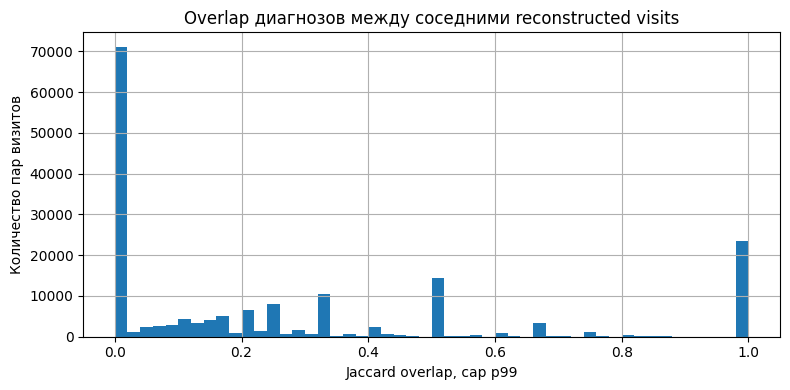

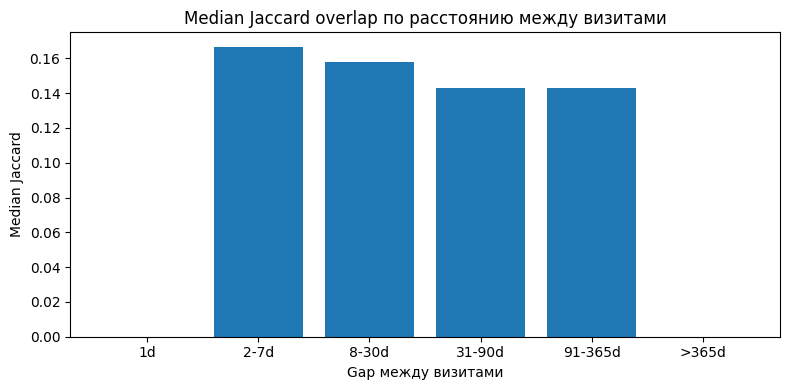

In [21]:
if len(pair_overlap) > 0:
    plt.figure(figsize=(8, 4))
    pair_overlap["jaccard"].clip(upper=pair_overlap["jaccard"].quantile(0.99)).hist(bins=50)
    plt.title("Overlap диагнозов между соседними reconstructed visits")
    plt.xlabel("Jaccard overlap, cap p99")
    plt.ylabel("Количество пар визитов")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    gap_plot = gap_overlap_summary.copy()
    plt.bar(gap_plot["gap_bin"].astype(str), gap_plot["median_jaccard"])
    plt.title("Median Jaccard overlap по расстоянию между визитами")
    plt.xlabel("Gap между визитами")
    plt.ylabel("Median Jaccard")
    plt.tight_layout()
    plt.show()

### Вывод по overlap диагнозов между reconstructed visits

Для анализа overlap мы восстановили приблизительные визиты через `Visit/...` события из `visit_occurrence`. Это более строгий вариант, потому что мы не используем служебные OMOP metadata-коды вроде `Domain/OMOP generated`.

Всего получилось **364,418 visit anchors** для **6,191 пациента**. После привязки diagnosis events к ближайшему предыдущему visit anchor удалось сопоставить **1,208,035 из 1,219,611 diagnosis events**, то есть около **99.1%**. Это показывает, что visit anchors хорошо покрывают diagnosis layer.

Дальше мы оставили только надежные привязки, где диагноз записан не позже чем через **30 дней после visit anchor**. В strict-версии осталось **1,102,498 diagnosis events** для **6,074 пациентов** и **8,552 diagnosis codes**. Медианный gap между visit anchor и diagnosis event составил **0.54 дня**, p90 — **9.29 дня**. Значит, большая часть diagnosis events действительно находится близко к соответствующему визиту.

После этого мы посчитали overlap diagnosis sets между соседними reconstructed visits. Для пары визитов используется коэффициент Жаккара:

```text
Jaccard = число общих diagnosis codes / число уникальных diagnosis codes в двух визитах
```

Всего найдено **176,420 пар соседних визитов**. Средний Jaccard overlap равен **0.275**, медианный — **0.143**, p75 — **0.5**, p90 — **1.0**. Медианное число общих diagnosis codes между соседними визитами — **1**, p90 — **2**.

Это означает, что у типичной пары соседних визитов overlap умеренный, но в верхнем хвосте diagnosis set может почти полностью повторяться. Такой высокий overlap может отражать copy-forwarding, перенос problem list или реальную стабильность хронических / persistent состояний.

Overlap зависит от расстояния между визитами. Для визитов с gap **2–7 дней** median Jaccard равен **0.167**, а для gap **>365 дней** median Jaccard падает до **0.0**. Это ожидаемо: чем ближе визиты во времени, тем выше вероятность, что одни и те же диагнозы будут повторно задокументированы.

Самые часто переносимые между соседними визитами коды — это не случайные acute events, а долгосрочные состояния и persistent status concepts: эссенциальная артериальная гипертензия, гиперлипидемия, сахарный диабет 2 типа, терминальная стадия хронической болезни почек, фибрилляция предсердий, сердечная недостаточность, а также статусы трансплантации. Поэтому overlap подтверждает основную гипотезу: repeated diagnosis documentation в EHRSHOT действительно связано с долгосрочными состояниями и может раздувать patient histories.

Важно: overlap не доказывает copy-forwarding напрямую. Мы интерпретируем его как proxy-сигнал повторного документирования диагнозов между визитами.

## 6. Leakage-safe аудит историй для `guo_readmission` и `guo_icu`

Для каждой label row строим историю пациента только до `prediction_time`.

На уровне prediction example считаем:

- raw sequence length без static demographics;
- сколько diagnosis events есть в истории;
- сколько diagnosis events являются повторами;
- сколько событий удалит first-last compression;
- насколько много persistent diagnosis codes есть у пациента.

Важно: в этом audit section first-last compression считается как верхняя оценка потенциального сокращения diagnosis layer для всех `condition_occurrence` codes. В последующих sequence experiments compression применяется строже — только к empirical chronic-like diagnosis codes из whitelist.

In [22]:
def make_legal_history_lf(
    labels: pl.DataFrame,
    include_prediction_time: bool = True,
    keep_columns: list[str] | None = None,
) -> pl.LazyFrame:
    if keep_columns is None:
        keep_columns = [
            "subject_id",
            "time",
            "code",
            "numeric_value",
            "text_value",
            "unit",
            "omop_table",
        ]

    labels_key_lf = labels.lazy().select([
        "task",
        "row_id",
        "subject_id",
        "prediction_time",
        "label",
        "split",
    ])

    history = events_lf.select(keep_columns).join(labels_key_lf, on="subject_id", how="inner")

    if include_prediction_time:
        history = history.filter(pl.col("time") <= pl.col("prediction_time"))
    else:
        history = history.filter(pl.col("time") < pl.col("prediction_time"))

    return history


def build_task_history_audit(task_name: str, labels: pl.DataFrame, use_cache: bool = True) -> pd.DataFrame:
    cache_path = RESULTS_DIR / f"task_history_copy_forwarding_audit__{task_name}.csv"
    if use_cache and cache_path.exists():
        print(f"[{task_name}] Loading cached audit: {cache_path}")
        return pd.read_csv(cache_path, parse_dates=["prediction_time", "first_event_time", "last_event_time"])

    print(f"[{task_name}] Building legal history stats...")
    history_lf = make_legal_history_lf(labels)

    raw_counts = (
        history_lf
        .filter(non_static_expr())
        .group_by("row_id")
        .agg([
            pl.len().alias("raw_sequence_length_non_static"),
            pl.col("code").n_unique().alias("raw_unique_codes_non_static"),
            pl.col("time").min().alias("first_event_time"),
            pl.col("time").max().alias("last_event_time"),
            pl.col("omop_table").n_unique().alias("n_omop_tables_before"),
        ])
        .with_columns([
            (pl.col("last_event_time") - pl.col("first_event_time")).dt.total_days().alias("history_span_days"),
        ])
    )

    diag_events = (
        history_lf
        .filter(diagnosis_like_expr())
        .with_columns(pl.col("time").dt.date().alias("event_date"))
    )

    row_code_diag = (
        diag_events
        .group_by(["row_id", "code"])
        .agg([
            pl.len().alias("n_events_for_diag_code"),
            pl.col("event_date").n_unique().alias("n_days_for_diag_code"),
            pl.col("time").min().alias("first_diag_code_time"),
            pl.col("time").max().alias("last_diag_code_time"),
        ])
        .with_columns([
            (pl.col("last_diag_code_time") - pl.col("first_diag_code_time")).dt.total_days().alias("diag_code_span_days"),
            (pl.col("n_events_for_diag_code") - 1).clip(lower_bound=0).alias("duplicate_events_for_diag_code"),
            (pl.col("n_days_for_diag_code") - 1).clip(lower_bound=0).alias("duplicate_days_for_diag_code"),
            pl.when(pl.col("n_events_for_diag_code") >= 2).then(2).otherwise(1).alias("first_last_kept_events_for_diag_code"),
        ])
    )

    diag_row_stats = (
        row_code_diag
        .group_by("row_id")
        .agg([
            pl.len().alias("n_unique_diag_codes"),
            pl.col("n_events_for_diag_code").sum().alias("n_diag_events_raw"),
            pl.col("duplicate_events_for_diag_code").sum().alias("n_diag_duplicate_events_over_first"),
            pl.col("duplicate_days_for_diag_code").sum().alias("n_diag_duplicate_days_over_first"),
            pl.col("first_last_kept_events_for_diag_code").sum().alias("n_diag_events_first_last"),
            (pl.col("n_events_for_diag_code") >= 2).sum().alias("n_diag_codes_repeated_event"),
            (pl.col("n_days_for_diag_code") >= 2).sum().alias("n_diag_codes_repeated_day"),
            ((pl.col("diag_code_span_days") >= 180) & (pl.col("n_days_for_diag_code") >= 2)).sum().alias("n_diag_codes_persistent_180d"),
            ((pl.col("diag_code_span_days") >= 365) & (pl.col("n_days_for_diag_code") >= 2)).sum().alias("n_diag_codes_persistent_365d"),
            pl.col("n_events_for_diag_code").max().alias("max_repeats_for_one_diag_code"),
            pl.col("diag_code_span_days").max().alias("max_diag_code_span_days"),
        ])
    )

    audit = (
        labels.lazy()
        .select(["task", "row_id", "subject_id", "prediction_time", "label", "split"])
        .join(raw_counts, on="row_id", how="left")
        .join(diag_row_stats, on="row_id", how="left")
        .with_columns([
            pl.col("raw_sequence_length_non_static").fill_null(0),
            pl.col("raw_unique_codes_non_static").fill_null(0),
            pl.col("n_omop_tables_before").fill_null(0),
            pl.col("history_span_days").fill_null(0),
            pl.col("n_unique_diag_codes").fill_null(0),
            pl.col("n_diag_events_raw").fill_null(0),
            pl.col("n_diag_duplicate_events_over_first").fill_null(0),
            pl.col("n_diag_duplicate_days_over_first").fill_null(0),
            pl.col("n_diag_events_first_last").fill_null(0),
            pl.col("n_diag_codes_repeated_event").fill_null(0),
            pl.col("n_diag_codes_repeated_day").fill_null(0),
            pl.col("n_diag_codes_persistent_180d").fill_null(0),
            pl.col("n_diag_codes_persistent_365d").fill_null(0),
            pl.col("max_repeats_for_one_diag_code").fill_null(0),
            pl.col("max_diag_code_span_days").fill_null(0),
        ])
        .with_columns([
            (
                pl.col("raw_sequence_length_non_static")
                - pl.col("n_diag_events_raw")
                + pl.col("n_unique_diag_codes")
            ).alias("compressed_sequence_length_first_only"),
            (
                pl.col("raw_sequence_length_non_static")
                - pl.col("n_diag_events_raw")
                + pl.col("n_diag_events_first_last")
            ).alias("compressed_sequence_length_first_last"),
        ])
        .with_columns([
            (pl.col("raw_sequence_length_non_static") - pl.col("compressed_sequence_length_first_only")).alias("repeat_removed_first_only"),
            (pl.col("raw_sequence_length_non_static") - pl.col("compressed_sequence_length_first_last")).alias("repeat_removed_first_last"),
            pl.when(pl.col("raw_sequence_length_non_static") > 0)
            .then(pl.col("compressed_sequence_length_first_last") / pl.col("raw_sequence_length_non_static"))
            .otherwise(None)
            .alias("compression_ratio_first_last"),
            pl.when(pl.col("raw_sequence_length_non_static") > 0)
            .then(pl.col("n_diag_duplicate_events_over_first") / pl.col("raw_sequence_length_non_static"))
            .otherwise(None)
            .alias("diag_duplicate_share_of_raw_sequence"),
            pl.when(pl.col("n_diag_events_raw") > 0)
            .then(pl.col("n_diag_duplicate_events_over_first") / pl.col("n_diag_events_raw"))
            .otherwise(None)
            .alias("diag_duplicate_share_of_diag_events"),
        ])
        .collect()
        .to_pandas()
    )

    audit.to_csv(cache_path, index=False)
    print("Saved:", cache_path)
    return audit


task_audit = {
    task_name: build_task_history_audit(task_name, labels, use_cache=True)
    for task_name, labels in labels_by_task.items()
}

[guo_readmission] Loading cached audit: ehrshot_copy_forwarding_audit/task_history_copy_forwarding_audit__guo_readmission.csv
[guo_icu] Loading cached audit: ehrshot_copy_forwarding_audit/task_history_copy_forwarding_audit__guo_icu.csv


In [23]:
def summarize_task_audit(stats: pd.DataFrame, task_name: str) -> pd.DataFrame:
    key_metrics = [
        "raw_sequence_length_non_static",
        "n_diag_events_raw",
        "n_unique_diag_codes",
        "n_diag_duplicate_events_over_first",
        "repeat_removed_first_last",
        "compression_ratio_first_last",
        "diag_duplicate_share_of_diag_events",
        "n_diag_codes_persistent_180d",
        "n_diag_codes_persistent_365d",
    ]

    rows = []
    for col in key_metrics:
        s = stats[col].dropna()
        rows.append({
            "task": task_name,
            "metric": col,
            "median": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "p95": s.quantile(0.95),
            "max": s.max(),
        })
    return pd.DataFrame(rows)


all_task_summary = []
for task_name, stats in task_audit.items():
    summary = summarize_task_audit(stats, task_name)
    all_task_summary.append(summary)

    print("\n" + "=" * 100)
    print(task_name)
    display_and_save(
        summary,
        RESULTS_DIR / f"task_history_copy_forwarding_summary_compact__{task_name}.csv",
        head=None,
    )

all_task_summary = pd.concat(all_task_summary, ignore_index=True)
display_and_save(
    all_task_summary,
    RESULTS_DIR / "task_history_copy_forwarding_summary_compact.csv",
    head=30,
)


guo_readmission
Saved: ehrshot_copy_forwarding_audit/task_history_copy_forwarding_summary_compact__guo_readmission.csv


,task,metric,median,p75,p90,p95,max
0,guo_readmission,raw_sequence_length_non_static,4574.000000,10206.000000,20944.600000,30533.300000,199907.000000
1,guo_readmission,n_diag_events_raw,70.000000,207.000000,554.800000,940.000000,3556.000000
2,guo_readmission,n_unique_diag_codes,31.000000,62.000000,109.800000,151.000000,445.000000
3,guo_readmission,n_diag_duplicate_events_over_first,39.000000,144.500000,444.000000,800.900000,3292.000000
4,guo_readmission,repeat_removed_first_last,26.000000,116.000000,388.800000,715.900000,3128.000000
5,guo_readmission,compression_ratio_first_last,0.993221,0.998254,1.000000,1.000000,1.000000
6,guo_readmission,diag_duplicate_share_of_diag_events,0.575758,0.735294,0.825719,0.860426,0.939328
7,guo_readmission,n_diag_codes_persistent_180d,2.000000,13.000000,33.000000,51.000000,208.000000
8,guo_readmission,n_diag_codes_persistent_365d,0.000000,8.000000,25.000000,40.000000,182.000000



guo_icu
Saved: ehrshot_copy_forwarding_audit/task_history_copy_forwarding_summary_compact__guo_icu.csv


,task,metric,median,p75,p90,p95,max
0,guo_icu,raw_sequence_length_non_static,3058.000000,7888.500000,17610.000000,27287.00000,151930.000000
1,guo_icu,n_diag_events_raw,47.000000,171.000000,505.000000,869.00000,3543.000000
2,guo_icu,n_unique_diag_codes,21.000000,51.000000,101.000000,143.00000,371.000000
3,guo_icu,n_diag_duplicate_events_over_first,25.000000,119.000000,406.000000,735.00000,3280.000000
4,guo_icu,repeat_removed_first_last,16.000000,95.000000,351.000000,662.50000,3116.000000
5,guo_icu,compression_ratio_first_last,0.993586,0.999212,1.000000,1.00000,1.000000
6,guo_icu,diag_duplicate_share_of_diag_events,0.571429,0.741935,0.829391,0.86206,0.937004
7,guo_icu,n_diag_codes_persistent_180d,1.000000,10.000000,30.000000,50.00000,171.000000
8,guo_icu,n_diag_codes_persistent_365d,0.000000,7.000000,24.000000,39.00000,146.000000


Saved: ehrshot_copy_forwarding_audit/task_history_copy_forwarding_summary_compact.csv


,task,metric,median,p75,p90,p95,max
0,guo_readmission,raw_sequence_length_non_static,4574.000000,10206.000000,20944.600000,30533.300000,199907.000000
1,guo_readmission,n_diag_events_raw,70.000000,207.000000,554.800000,940.000000,3556.000000
2,guo_readmission,n_unique_diag_codes,31.000000,62.000000,109.800000,151.000000,445.000000
3,guo_readmission,n_diag_duplicate_events_over_first,39.000000,144.500000,444.000000,800.900000,3292.000000
4,guo_readmission,repeat_removed_first_last,26.000000,116.000000,388.800000,715.900000,3128.000000
5,guo_readmission,compression_ratio_first_last,0.993221,0.998254,1.000000,1.000000,1.000000
6,guo_readmission,diag_duplicate_share_of_diag_events,0.575758,0.735294,0.825719,0.860426,0.939328
7,guo_readmission,n_diag_codes_persistent_180d,2.000000,13.000000,33.000000,51.000000,208.000000
8,guo_readmission,n_diag_codes_persistent_365d,0.000000,8.000000,25.000000,40.000000,182.000000
9,guo_icu,raw_sequence_length_non_static,3058.000000,7888.500000,17610.000000,27287.000000,151930.000000


In [24]:
for task_name, stats in task_audit.items():
    print("\n" + "=" * 100)
    print(task_name)

    by_split_label = (
        stats
        .groupby(["split", "label"], dropna=False)
        .agg(
            n_examples=("row_id", "size"),
            n_patients=("subject_id", "nunique"),
            raw_median=("raw_sequence_length_non_static", "median"),
            raw_p90=("raw_sequence_length_non_static", lambda x: x.quantile(0.90)),
            diag_events_median=("n_diag_events_raw", "median"),
            diag_dup_median=("n_diag_duplicate_events_over_first", "median"),
            removed_first_last_median=("repeat_removed_first_last", "median"),
            removed_first_last_p90=("repeat_removed_first_last", lambda x: x.quantile(0.90)),
            compression_ratio_median=("compression_ratio_first_last", "median"),
            duplicate_diag_share_median=("diag_duplicate_share_of_diag_events", "median"),
        )
        .reset_index()
    )

    display_and_save(by_split_label, RESULTS_DIR / f"task_history_summary_by_split_label__{task_name}.csv")


guo_readmission
Saved: ehrshot_copy_forwarding_audit/task_history_summary_by_split_label__guo_readmission.csv


,split,label,n_examples,n_patients,raw_median,raw_p90,diag_events_median,diag_dup_median,removed_first_last_median,removed_first_last_p90,compression_ratio_median,duplicate_diag_share_median
0,held_out,0,1929,1187,4516.0,20553.2,68.0,35.0,23.0,380.2,0.993715,0.564935
1,held_out,1,260,151,5345.0,19121.4,75.5,45.5,34.0,461.3,0.990486,0.645833
2,train,0,2238,1335,4371.5,20149.2,66.0,36.0,24.0,369.6,0.993540,0.565217
3,train,1,370,164,7696.5,39242.5,145.0,94.5,75.5,1018.8,0.988804,0.677419
4,tuning,0,1925,1187,4201.0,17716.8,65.0,34.0,23.0,291.6,0.993695,0.564309
5,tuning,1,281,159,5194.0,23153.0,104.0,64.0,48.0,515.0,0.989799,0.660714



guo_icu
Saved: ehrshot_copy_forwarding_audit/task_history_summary_by_split_label__guo_icu.csv


,split,label,n_examples,n_patients,raw_median,raw_p90,diag_events_median,diag_dup_median,removed_first_last_median,removed_first_last_p90,compression_ratio_median,duplicate_diag_share_median
0,held_out,0,1952,1125,3034.5,18014.1,46.0,24.0,15.0,374.8,0.993533,0.574167
1,held_out,1,85,75,3017.0,15467.4,44.0,20.0,9.0,223.6,0.995098,0.500000
2,train,0,2289,1269,3275.0,19174.0,49.0,26.0,17.0,400.8,0.993759,0.568796
3,train,1,113,107,2963.0,15268.0,68.0,39.0,30.0,314.0,0.987903,0.611940
4,tuning,0,1960,1121,2898.5,15263.8,44.0,25.0,16.5,284.0,0.993707,0.575696
5,tuning,1,92,84,2934.0,17346.8,73.0,40.5,30.5,417.5,0.989802,0.562745


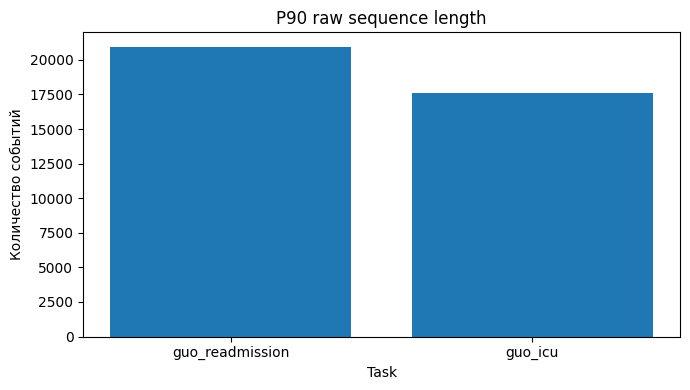

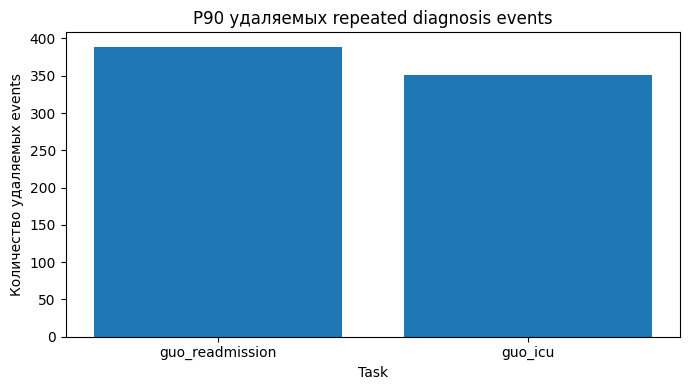

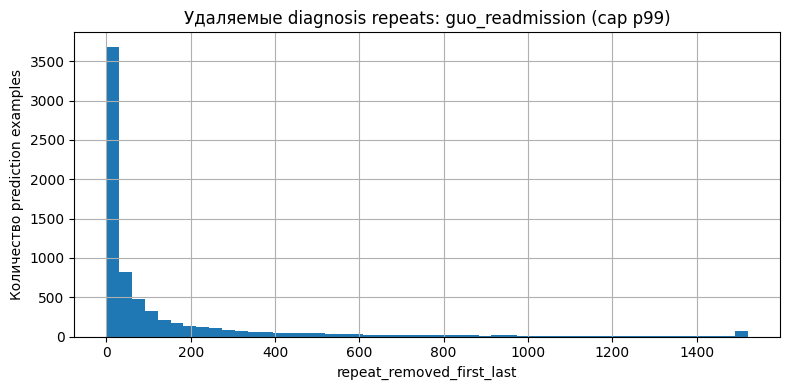

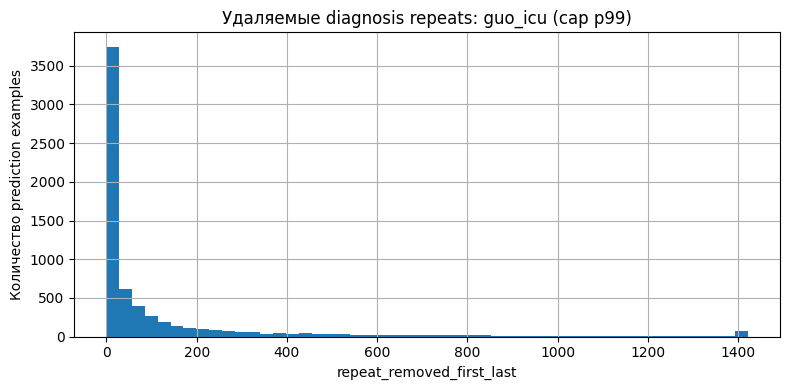

In [25]:
# Сводный график: p90 длины raw sequence и p90 удаляемых diagnosis repeats.
plot_rows = []
for task_name, stats in task_audit.items():
    plot_rows.append({
        "task": task_name,
        "p90_raw_sequence": stats["raw_sequence_length_non_static"].quantile(0.90),
        "p90_removed_repeats": stats["repeat_removed_first_last"].quantile(0.90),
        "median_removed_repeats": stats["repeat_removed_first_last"].median(),
    })

task_plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(7, 4))
plt.bar(task_plot_df["task"], task_plot_df["p90_raw_sequence"])
plt.title("P90 raw sequence length")
plt.xlabel("Task")
plt.ylabel("Количество событий")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(task_plot_df["task"], task_plot_df["p90_removed_repeats"])
plt.title("P90 удаляемых repeated diagnosis events")
plt.xlabel("Task")
plt.ylabel("Количество удаляемых events")
plt.tight_layout()
plt.show()

# По одной гистограмме на задачу: насколько сильный хвост у removed repeats.
for task_name, stats in task_audit.items():
    values = stats["repeat_removed_first_last"].dropna()
    cap = values.quantile(0.99)

    plt.figure(figsize=(8, 4))
    values.clip(upper=cap).hist(bins=50)
    plt.title(f"Удаляемые diagnosis repeats: {task_name} (cap p99)")
    plt.xlabel("repeat_removed_first_last")
    plt.ylabel("Количество prediction examples")
    plt.tight_layout()
    plt.show()

### Краткий вывод

- Для медианного пациента compression почти не меняет всю sequence, потому что event stream доминируется измерениями.
- Но в верхнем хвосте эффект заметный: p90 удаляемых diagnosis repeats — сотни событий.
- `guo_readmission` имеет более высокий event rate и сильнее связан с burden повторяющихся диагнозов.
- `guo_icu` более редкая задача; repeated diagnoses там скорее помогают сократить длину истории, но не обязательно повышают event rate.

## 7. Кому compression помогает больше всего?

Выделяем high-repeat group: top 10% prediction examples по числу repeated diagnosis events, которые удаляются first-last compression.

Это не модельная метрика. Это ответ на вопрос: у каких пациентов history сильнее всего раздута повторяющимися диагнозами.


guo_readmission
Saved: ehrshot_copy_forwarding_audit/high_repeat_group_summary__guo_readmission.csv


,task,repeat_removed_threshold_p90,high_repeat_group,n_examples,n_patients,event_rate,raw_median,repeat_removed_median,compression_ratio_median,duplicate_diag_share_median,persistent_180d_codes_median,persistent_365d_codes_median
0,guo_readmission,388.8,False,6302,3685,0.120121,3889.5,19.0,0.994473,0.544821,1.0,0.0
1,guo_readmission,388.8,True,701,229,0.219686,27556.0,716.0,0.971317,0.853070,51.0,38.0


Saved: ehrshot_copy_forwarding_audit/top_repeat_examples__guo_readmission.csv
Showing first 8 rows out of 20


,task,row_id,subject_id,prediction_time,label,split,raw_sequence_length_non_static,repeat_removed_first_last,compression_ratio_first_last,n_diag_codes_persistent_365d
1451,guo_readmission,1451,115972598,2015-06-09 23:59:00,0,train,64900,3128,0.951803,88
1450,guo_readmission,1450,115972598,2014-10-13 23:59:00,0,train,60770,2884,0.952542,78
6768,guo_readmission,6768,115967178,2022-06-06 23:59:00,0,tuning,41525,2759,0.933558,143
3175,guo_readmission,3175,115971275,2022-05-15 23:59:00,0,tuning,51941,2739,0.947267,75
1449,guo_readmission,1449,115972598,2014-06-10 23:59:00,0,train,56017,2735,0.951176,70
3174,guo_readmission,3174,115971275,2022-02-28 23:59:00,0,tuning,49980,2653,0.946919,74
1448,guo_readmission,1448,115972598,2014-04-24 23:59:00,0,train,53097,2632,0.950430,62
3238,guo_readmission,3238,115970694,2022-12-02 23:59:00,0,train,59550,2625,0.955919,86



guo_icu
Saved: ehrshot_copy_forwarding_audit/high_repeat_group_summary__guo_icu.csv


,task,repeat_removed_threshold_p90,high_repeat_group,n_examples,n_patients,event_rate,raw_median,repeat_removed_median,compression_ratio_median,duplicate_diag_share_median,persistent_180d_codes_median,persistent_365d_codes_median
0,guo_icu,351.0,False,5840,3577,0.045034,2511.5,11.0,0.995100,0.529412,1.0,0.0
1,guo_icu,351.0,True,651,231,0.041475,24436.0,662.0,0.970707,0.847711,48.0,38.0


Saved: ehrshot_copy_forwarding_audit/top_repeat_examples__guo_icu.csv
Showing first 8 rows out of 20


,task,row_id,subject_id,prediction_time,label,split,raw_sequence_length_non_static,repeat_removed_first_last,compression_ratio_first_last,n_diag_codes_persistent_365d
1579,guo_icu,1579,115972598,2015-06-08 23:59:00,0,train,64780,3116,0.951899,88
1578,guo_icu,1578,115972598,2014-10-11 23:59:00,0,train,60444,2866,0.952584,74
6240,guo_icu,6240,115967178,2022-06-01 23:59:00,0,tuning,41042,2743,0.933166,141
3031,guo_icu,3031,115971275,2022-05-08 23:59:00,0,tuning,50818,2729,0.946299,74
1577,guo_icu,1577,115972598,2014-05-31 23:59:00,0,train,54391,2699,0.950378,67
3030,guo_icu,3030,115971275,2022-02-23 23:59:00,0,tuning,49641,2642,0.946778,73
1576,guo_icu,1576,115972598,2014-04-18 23:59:00,0,train,51753,2611,0.949549,56
3069,guo_icu,3069,115970694,2022-11-15 23:59:00,0,train,55610,2587,0.953480,83


Saved: ehrshot_copy_forwarding_audit/high_repeat_group_summary_all_tasks.csv


,task,repeat_removed_threshold_p90,high_repeat_group,n_examples,n_patients,event_rate,raw_median,repeat_removed_median,compression_ratio_median,duplicate_diag_share_median,persistent_180d_codes_median,persistent_365d_codes_median
0,guo_readmission,388.8,False,6302,3685,0.120121,3889.5,19.0,0.994473,0.544821,1.0,0.0
1,guo_readmission,388.8,True,701,229,0.219686,27556.0,716.0,0.971317,0.853070,51.0,38.0
2,guo_icu,351.0,False,5840,3577,0.045034,2511.5,11.0,0.995100,0.529412,1.0,0.0
3,guo_icu,351.0,True,651,231,0.041475,24436.0,662.0,0.970707,0.847711,48.0,38.0


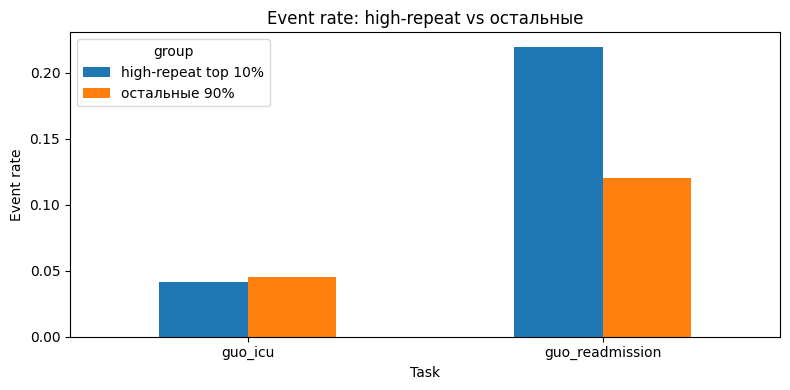

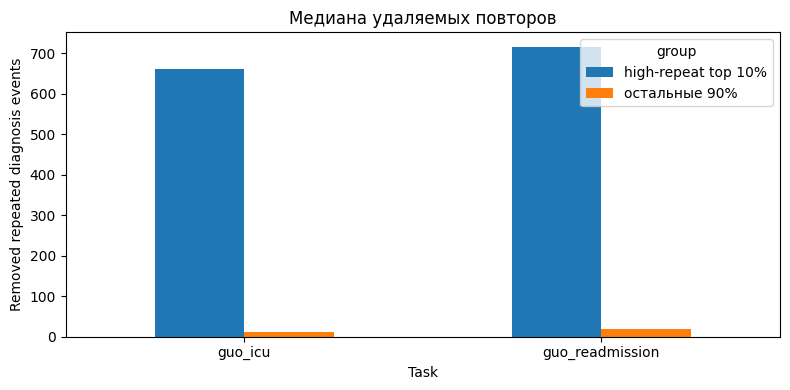

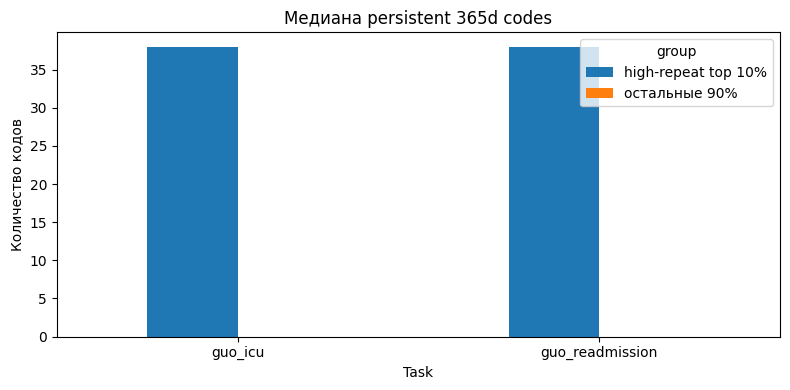

In [26]:
def high_repeat_group_audit(stats: pd.DataFrame, task_name: str, q: float = 0.90) -> tuple[pd.DataFrame, pd.DataFrame]:
    threshold = stats["repeat_removed_first_last"].quantile(q)
    out = stats.copy()
    out["high_repeat_group"] = out["repeat_removed_first_last"] >= threshold

    group_summary = (
        out
        .groupby("high_repeat_group")
        .agg(
            n_examples=("row_id", "size"),
            n_patients=("subject_id", "nunique"),
            event_rate=("label", "mean"),
            raw_median=("raw_sequence_length_non_static", "median"),
            repeat_removed_median=("repeat_removed_first_last", "median"),
            compression_ratio_median=("compression_ratio_first_last", "median"),
            duplicate_diag_share_median=("diag_duplicate_share_of_diag_events", "median"),
            persistent_180d_codes_median=("n_diag_codes_persistent_180d", "median"),
            persistent_365d_codes_median=("n_diag_codes_persistent_365d", "median"),
        )
        .reset_index()
    )

    group_summary.insert(0, "task", task_name)
    group_summary.insert(1, "repeat_removed_threshold_p90", threshold)

    top_examples = out.sort_values("repeat_removed_first_last", ascending=False).head(20)
    return group_summary, top_examples


high_repeat_summaries = []
top_repeat_examples_by_task = {}

for task_name, stats in task_audit.items():
    group_summary, top_examples = high_repeat_group_audit(stats, task_name)
    high_repeat_summaries.append(group_summary)
    top_repeat_examples_by_task[task_name] = top_examples

    print("\n" + "=" * 100)
    print(task_name)
    display_and_save(group_summary, RESULTS_DIR / f"high_repeat_group_summary__{task_name}.csv", head=None)

    display_and_save(
        top_examples[[
            "task", "row_id", "subject_id", "prediction_time", "label", "split",
            "raw_sequence_length_non_static", "repeat_removed_first_last",
            "compression_ratio_first_last", "n_diag_codes_persistent_365d",
        ]],
        RESULTS_DIR / f"top_repeat_examples__{task_name}.csv",
        head=8,
    )

high_repeat_summaries = pd.concat(high_repeat_summaries, ignore_index=True)
display_and_save(high_repeat_summaries, RESULTS_DIR / "high_repeat_group_summary_all_tasks.csv", head=None)

# График: event rate в high-repeat vs остальных.
plot_df = high_repeat_summaries.copy()
plot_df["group"] = plot_df["high_repeat_group"].map({False: "остальные 90%", True: "high-repeat top 10%"})

for metric, title, ylabel in [
    ("event_rate", "Event rate: high-repeat vs остальные", "Event rate"),
    ("repeat_removed_median", "Медиана удаляемых повторов", "Removed repeated diagnosis events"),
    ("persistent_365d_codes_median", "Медиана persistent 365d codes", "Количество кодов"),
]:
    pivot = plot_df.pivot(index="task", columns="group", values=metric)
    pivot.plot(kind="bar", figsize=(8, 4))
    plt.title(title)
    plt.xlabel("Task")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Краткий вывод

- High-repeat group — это пациенты с самым сильным раздуванием diagnosis layer.
- В этой группе first-last compression удаляет уже не десятки, а сотни diagnosis repeats.
- Для `guo_readmission` high-repeat group имеет более высокий event rate, значит repeated diagnosis burden может быть связан с риском readmission.
- Для `guo_icu` high-repeat group в первую очередь показывает длинные истории, но не обязательно более высокий label risk.

## 8. Какие диагнозы раздувают истории в задачах?

Теперь смотрим не глобальные repeats, а repeats именно внутри legal histories для `guo_readmission` и `guo_icu`.

Это важно: код может часто повторяться в датасете в целом, но не быть главным драйвером compression в конкретной prediction task.


guo_readmission
[guo_readmission] Loading cached repeated code table: ehrshot_copy_forwarding_audit/repeated_diagnosis_codes_inside_histories__guo_readmission.csv
Saved: ehrshot_copy_forwarding_audit/repeated_diagnosis_codes_inside_histories_compact_ru__guo_readmission.csv


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_prediction_examples_with_code,n_events_in_histories,n_duplicate_events_in_histories,duplicate_event_share_in_histories,persistent_365d_example_share,event_rate_among_examples_with_code
0,SNOMED/737296002,Transplanted lung present — наличие трансплант...,Observation,Clinical Finding,361,29941,29580,0.987943,0.373961,0.279778
1,SNOMED/59621000,Essential hypertension — эссенциальная артериа...,Condition,Disorder,3400,24565,21165,0.861592,0.389706,0.121176
2,SNOMED/37151006,Erythromelalgia — перевод не задан,Condition,Disorder,64,15236,15172,0.995799,1.000000,0.062500
3,SNOMED/81423003,Cystic fibrosis without meconium ileus — перев...,Condition,Disorder,164,12969,12805,0.987354,0.743902,0.207317
4,SNOMED/46177005,End-stage renal disease — терминальная стадия ...,Condition,Disorder,407,13100,12693,0.968931,0.432432,0.179361
5,SNOMED/313436004,Type 2 diabetes mellitus without complication ...,Condition,Disorder,1567,13799,12232,0.886441,0.379706,0.142310
6,SNOMED/372010005,Primary malignant neoplasm of soft tissues — п...,Condition,Disorder,255,11728,11473,0.978257,0.392157,0.384314
7,SNOMED/82423001,Chronic pain — хроническая боль,Condition,Clinical Finding,1389,12444,11055,0.888380,0.328294,0.091433
8,SNOMED/55822004,Hyperlipidemia — гиперлипидемия,Condition,Disorder,2519,13190,10671,0.809022,0.349345,0.115522
9,SNOMED/91861009,"Acute myeloid leukemia, disease — перевод не з...",Condition,Disorder,260,10915,10655,0.976180,0.223077,0.269231


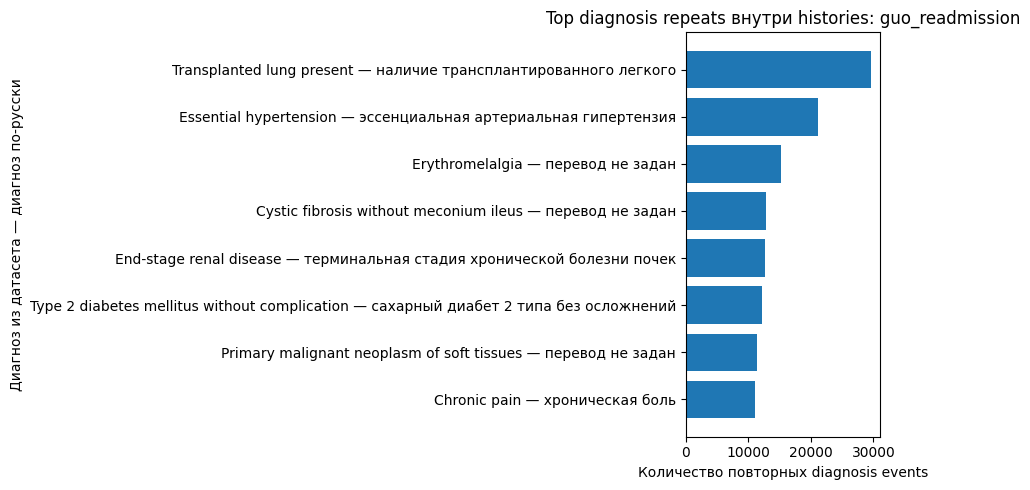


guo_icu
[guo_icu] Loading cached repeated code table: ehrshot_copy_forwarding_audit/repeated_diagnosis_codes_inside_histories__guo_icu.csv
Saved: ehrshot_copy_forwarding_audit/repeated_diagnosis_codes_inside_histories_compact_ru__guo_icu.csv


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_prediction_examples_with_code,n_events_in_histories,n_duplicate_events_in_histories,duplicate_event_share_in_histories,persistent_365d_example_share,event_rate_among_examples_with_code
0,SNOMED/737296002,Transplanted lung present — наличие трансплант...,Observation,Clinical Finding,264,23895,23631,0.988952,0.462121,0.045455
1,SNOMED/59621000,Essential hypertension — эссенциальная артериа...,Condition,Disorder,2555,19983,17428,0.872141,0.416438,0.045793
2,SNOMED/37151006,Erythromelalgia — перевод не задан,Condition,Disorder,65,15566,15501,0.995824,1.000000,0.000000
3,SNOMED/81423003,Cystic fibrosis without meconium ileus — перев...,Condition,Disorder,156,12392,12236,0.987411,0.756410,0.057692
4,SNOMED/372010005,Primary malignant neoplasm of soft tissues — п...,Condition,Disorder,232,11122,10890,0.979140,0.405172,0.025862
5,SNOMED/82423001,Chronic pain — хроническая боль,Condition,Clinical Finding,1019,11198,10179,0.909002,0.378803,0.024534
6,SNOMED/46177005,End-stage renal disease — терминальная стадия ...,Condition,Disorder,303,10435,10132,0.970963,0.518152,0.072607
7,SNOMED/313436004,Type 2 diabetes mellitus without complication ...,Condition,Disorder,1148,11266,10118,0.898100,0.416376,0.056620
8,SNOMED/86555001,Cystic fibrosis of the lung — перевод не задан,Condition,Disorder,158,9305,9147,0.983020,0.727848,0.056962
9,SNOMED/91861009,"Acute myeloid leukemia, disease — перевод не з...",Condition,Disorder,225,9239,9014,0.975647,0.182222,0.075556


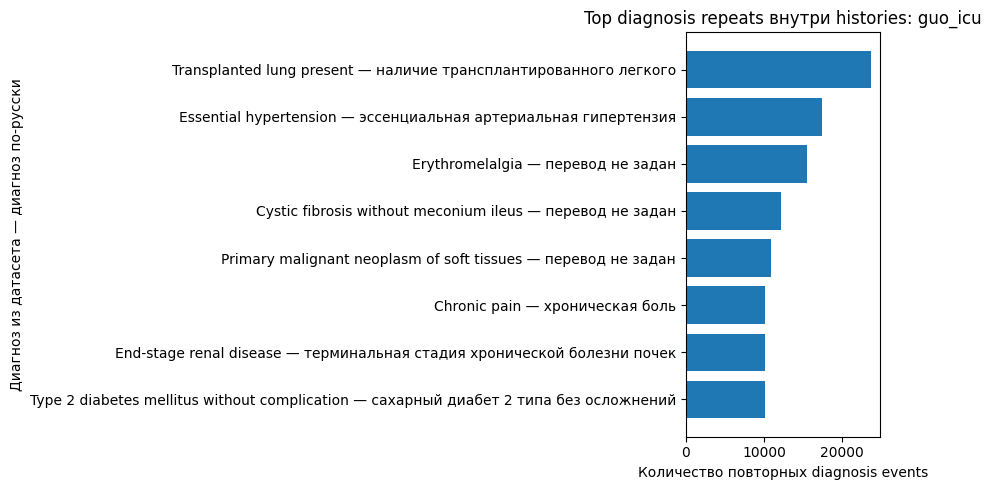

In [27]:
def repeated_codes_inside_task_histories(task_name: str, labels: pl.DataFrame, use_cache: bool = True) -> pd.DataFrame:
    cache_path = RESULTS_DIR / f"repeated_diagnosis_codes_inside_histories__{task_name}.csv"
    if use_cache and cache_path.exists():
        print(f"[{task_name}] Loading cached repeated code table: {cache_path}")
        out = pd.read_csv(cache_path)
        # Старые cache-файлы могли быть без Athena names. Обновим metadata поверх.
        if "diagnosis_dataset_to_ru" not in out.columns:
            out = attach_code_descriptions(out[[c for c in out.columns if c not in {
                "diagnosis_name", "concept_name", "domain_id", "vocabulary_id",
                "concept_class_id", "standard_concept", "invalid_reason",
                "diagnosis_name_ru", "diagnosis_dataset_to_ru"
            }]])
        return out

    history_lf = make_legal_history_lf(labels)
    diag_hist = history_lf.filter(diagnosis_like_expr()).with_columns(
        pl.col("time").dt.date().alias("event_date")
    )

    row_code = (
        diag_hist
        .group_by(["row_id", "code"])
        .agg([
            pl.len().alias("n_events_for_code_in_example"),
            pl.col("event_date").n_unique().alias("n_days_for_code_in_example"),
            pl.col("time").min().alias("first_time_in_example"),
            pl.col("time").max().alias("last_time_in_example"),
        ])
        .with_columns([
            (pl.col("last_time_in_example") - pl.col("first_time_in_example")).dt.total_days().alias("span_days_in_example"),
            (pl.col("n_events_for_code_in_example") - 1).clip(lower_bound=0).alias("duplicate_events_in_example"),
            (pl.col("n_days_for_code_in_example") - 1).clip(lower_bound=0).alias("duplicate_days_in_example"),
        ])
    )

    code_stats = (
        row_code
        .join(labels.lazy().select(["row_id", "subject_id", "label", "split"]), on="row_id", how="left")
        .group_by("code")
        .agg([
            pl.len().alias("n_prediction_examples_with_code"),
            pl.col("subject_id").n_unique().alias("n_subjects_with_code_in_histories"),
            pl.col("n_events_for_code_in_example").sum().alias("n_events_in_histories"),
            pl.col("duplicate_events_in_example").sum().alias("n_duplicate_events_in_histories"),
            (pl.col("n_events_for_code_in_example") >= 2).mean().alias("repeat_example_share_event"),
            ((pl.col("span_days_in_example") >= 365) & (pl.col("n_days_for_code_in_example") >= 2)).mean().alias("persistent_365d_example_share"),
            pl.col("span_days_in_example").median().alias("median_span_days_per_example"),
            pl.col("label").mean().alias("event_rate_among_examples_with_code"),
        ])
        .with_columns([
            (pl.col("n_duplicate_events_in_histories") / pl.col("n_events_in_histories")).alias("duplicate_event_share_in_histories"),
        ])
        .sort(["n_duplicate_events_in_histories", "n_prediction_examples_with_code"], descending=True)
        .collect()
    )

    out = attach_code_descriptions(code_stats)
    out.to_csv(cache_path, index=False)
    print("Saved:", cache_path)
    return out


repeated_codes_by_task = {}

for task_name, labels in labels_by_task.items():
    print("\n" + "=" * 100)
    print(task_name)

    repeated_codes_by_task[task_name] = repeated_codes_inside_task_histories(task_name, labels, use_cache=True)

    compact = compact_diagnosis_table(
        repeated_codes_by_task[task_name],
        [
            "code",
            "diagnosis_dataset_to_ru",
            "domain_id",
            "concept_class_id",
            "n_prediction_examples_with_code",
            "n_events_in_histories",
            "n_duplicate_events_in_histories",
            "duplicate_event_share_in_histories",
            "persistent_365d_example_share",
            "event_rate_among_examples_with_code",
        ],
        n=12,
    )

    display_and_save(
        compact,
        RESULTS_DIR / f"repeated_diagnosis_codes_inside_histories_compact_ru__{task_name}.csv",
        head=None,
    )

    plot_df = compact.head(8).copy()
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["diagnosis_dataset_to_ru"][::-1], plot_df["n_duplicate_events_in_histories"][::-1])
    plt.title(f"Top diagnosis repeats внутри histories: {task_name}")
    plt.xlabel("Количество повторных diagnosis events")
    plt.ylabel("Диагноз из датасета — диагноз по-русски")
    plt.tight_layout()
    plt.show()

### Краткий вывод

- В обеих задачах compression в основном затрагивает долгосрочные repeated conditions.
- Главные драйверы повторов:
  - `Essential hypertension — эссенциальная артериальная гипертензия`;
  - `Hyperlipidemia — гиперлипидемия`;
  - `Type 2 diabetes mellitus without complication — сахарный диабет 2 типа без осложнений`;
  - `End-stage renal disease — терминальная стадия хронической болезни почек`;
  - `Atrial fibrillation — фибрилляция предсердий`;
  - `Congestive heart failure — застойная сердечная недостаточность`.
- Это поддерживает идею persistence-aware compression: сохранять первое появление, последнее появление и summary о частоте/длительности, а не каждое повторное упоминание.

## 9. Ручная проверка самых compressible examples

Берем top examples, где first-last compression удаляет больше всего diagnosis repeats, и смотрим, какие коды повторяются внутри конкретного пациента.

Это sanity check: нужно убедиться, что compression удаляет именно repeated long-term documentation, а не разные важные acute events.

In [28]:
def inspect_repeated_diagnoses_for_example(
    task_name: str,
    row_id: int,
    top_n: int = 12,
) -> pd.DataFrame:
    labels = labels_by_task[task_name]
    one_label = labels.filter(pl.col("row_id") == row_id)
    assert one_label.height == 1, f"row_id={row_id} not found for {task_name}"

    diag_hist = (
        make_legal_history_lf(one_label)
        .filter(diagnosis_like_expr())
        .with_columns(pl.col("time").dt.date().alias("event_date"))
    )

    repeated = (
        diag_hist
        .group_by("code")
        .agg([
            pl.len().alias("n_events"),
            pl.col("event_date").n_unique().alias("n_days"),
            pl.col("time").min().alias("first_time"),
            pl.col("time").max().alias("last_time"),
        ])
        .with_columns([
            (pl.col("last_time") - pl.col("first_time")).dt.total_days().alias("span_days"),
            (pl.col("n_events") - 1).clip(lower_bound=0).alias("duplicate_events_over_first"),
        ])
        .sort(["duplicate_events_over_first", "n_days", "span_days"], descending=True)
        .head(top_n)
        .collect()
    )

    out = attach_code_descriptions(repeated)
    return compact_diagnosis_table(
        out,
        [
            "code",
            "diagnosis_dataset_to_ru",
            "domain_id",
            "concept_class_id",
            "n_events",
            "n_days",
            "span_days",
            "duplicate_events_over_first",
        ],
        n=top_n,
    )


for task_name, top_examples in top_repeat_examples_by_task.items():
    if len(top_examples) == 0:
        continue

    row_id = int(top_examples.iloc[0]["row_id"])
    print("\n" + "=" * 100)
    print(f"{task_name}: top compressible row_id={row_id}")

    display(inspect_repeated_diagnoses_for_example(task_name, row_id, top_n=12))


guo_readmission: top compressible row_id=1451


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_events,n_days,span_days,duplicate_events_over_first
0,SNOMED/118599009,Hodgkin's disease (clinical) — перевод не задан,Condition,Disorder,389,389,2374,388
1,SNOMED/737300001,Bone marrow transplant present — перевод не задан,Observation,Clinical Finding,265,265,2300,264
2,SNOMED/428103008,Disorder of transplanted bone marrow — перевод...,Condition,Disorder,229,229,1244,228
3,SNOMED/234646005,Graft versus host disease — перевод не задан,Condition,Disorder,147,147,1219,146
4,SNOMED/274710003,Lung field abnormal — перевод не задан,Condition,Clinical Finding,109,109,1936,108
5,SNOMED/271503005,Empyema with fistula — перевод не задан,Condition,Disorder,106,106,1247,105
6,SNOMED/37981002,Allergic bronchopulmonary aspergillosis — пере...,Condition,Disorder,95,95,1282,94
7,SNOMED/30746006,Lymphadenopathy — перевод не задан,Condition,Disorder,94,94,1580,93
8,SNOMED/191222008,Hemoglobinuria due to hemolysis from external ...,Condition,Disorder,86,86,1286,85
9,SNOMED/442073005,Infection by methicillin sensitive Staphylococ...,Condition,Disorder,86,86,935,85



guo_icu: top compressible row_id=1579


,code,diagnosis_dataset_to_ru,domain_id,concept_class_id,n_events,n_days,span_days,duplicate_events_over_first
0,SNOMED/118599009,Hodgkin's disease (clinical) — перевод не задан,Condition,Disorder,388,388,2374,387
1,SNOMED/737300001,Bone marrow transplant present — перевод не задан,Observation,Clinical Finding,264,264,2298,263
2,SNOMED/428103008,Disorder of transplanted bone marrow — перевод...,Condition,Disorder,229,229,1244,228
3,SNOMED/234646005,Graft versus host disease — перевод не задан,Condition,Disorder,146,146,1218,145
4,SNOMED/274710003,Lung field abnormal — перевод не задан,Condition,Clinical Finding,109,109,1936,108
5,SNOMED/271503005,Empyema with fistula — перевод не задан,Condition,Disorder,106,106,1247,105
6,SNOMED/37981002,Allergic bronchopulmonary aspergillosis — пере...,Condition,Disorder,95,95,1282,94
7,SNOMED/30746006,Lymphadenopathy — перевод не задан,Condition,Disorder,94,94,1580,93
8,SNOMED/191222008,Hemoglobinuria due to hemolysis from external ...,Condition,Disorder,86,86,1286,85
9,SNOMED/442073005,Infection by methicillin sensitive Staphylococ...,Condition,Disorder,86,86,935,85


### Краткий вывод

- В самых compressible examples повторы идут не только в рамках одного дня.
- У top patients один и тот же diagnosis code может повторяться сотни раз на протяжении нескольких лет.
- Это подтверждает, что проблема не сводится к случайным дублям: часть diagnosis layer — это долговременное repeated documentation.

## 10. Итоговый вывод

Аудит показывает, что repeated diagnosis documentation в EHRSHOT действительно есть, но она устроена неоднородно.

Главные результаты:

1. Весь event stream доминируется `measurement`, поэтому diagnosis compression не решает всю проблему длины sequence.
2. Внутри `condition_occurrence` повторы выражены сильно: у медианного пациента есть десятки repeated diagnosis events.
3. Самые частые повторы соответствуют понятным долгосрочным состояниям: гипертензия, гиперлипидемия, диабет 2 типа, терминальная болезнь почек, фибрилляция предсердий, сердечная недостаточность.
4. У high-repeat пациентов first-last compression удаляет уже сотни diagnosis repeats.
5. Для `guo_readmission` high-repeat group имеет более высокий event rate, поэтому repeated diagnosis burden может быть связан с риском readmission.
6. Для `guo_icu` compression полезна прежде всего как сокращение длинных историй, но связь с label risk слабее.

Практический вывод для следующих экспериментов:

- не удалять diagnosis repeats полностью;
- сохранять первое появление диагноза;
- сохранять последнее появление;
- добавлять summary-признаки: `count`, `span`, `n_days`, persistent flags;
- отдельно анализировать strict chronic diagnoses (`Condition + Disorder`) и persistent findings/status concepts.

# Краткая численная сводка

- Всего событий: 41,661,637
- Пациентов: 6,739
- Уникальных кодов: 31,252

## Diagnosis-like слой
- `condition_occurrence` events: 1,219,611
- Пациентов с diagnosis-like событиями: 6,144
- Уникальных diagnosis codes: 8,759
- Athena name coverage: 1.000

## Chronic-like группы
- `not_chronic_like_by_empirical_rule`: 7,231 codes
- `possible_chronic_like`: 667 codes
- `strong_chronic_like`: 444 codes
- `repeated_short_span`: 417 codes

## Task-level compression

### guo_readmission
- n examples: 7,003
- event rate: 0.130
- median raw sequence length: 4574.0
- p90 raw sequence length: 20944.6
- median removed diagnosis repeats: 26.0
- p90 removed diagnosis repeats: 388.8
- median first-last compression ratio: 0.993

### guo_icu
- n examples: 6,491
- event rate: 0.045
- median raw sequence length: 3058.0
- p90 raw sequence length: 17610.0
- median removed diagnosis repeats: 16.0
- p90 removed diagnosis repeats: 351.0
- median first-last compression ratio: 0.994

Этот audit notebook использовался как основание для следующих sequence experiments: файл `strong_empirical_chronic_like_diagnosis_codes.csv` стал whitelist для compression-aware sequence datasets.